In [3]:
# global imports
import networkx as ntx
import matplotlib.pyplot as plt
import numpy as np
import math 

# type definition section
type Edges = list[tuple[int, int]]
type Edge  = tuple[int, int]


In [40]:
"""
    What I have to achieve is a scale-free network through preferential attachment 
    The point is to mimic the behaviour of a real network over time
    !!! FOR THE RATE OF GROWTH !!! we will use the information from https://backlinko.com/social-media-users#global-social-media-growth-rates
    where the actuall rate of growth will be reported as a net mean number of people added over last 10 year 
    reported to the population of the earth.
"""
"""
    2025: 5.24 billion active users (+4.1%)
    2024: 5.04 billion active users (+5.8%)
    2023: 4.76 billion active users (+3%)
    2022: 4.62 billion active users (+10%)
    2021: 4.20 billion active users (+13%)
    2020: 3.71 billion active users (+7.2%)
    2019: 3.46 billion active users (+8.3%)
    2018: 3.20 billion active users (+15%)
    2017: 2.79 billion active users (+21%)
    2016: 2.31 billion active users (+11%)
    2015: 2.08 billion active users
    """

class SynthNetwork:
    def __init__(self, N:list|None):
        # default number of nodes in the graph
        if not N:
            self.N:list = [x for x in range(25)]
        else:
            self.N = N
        # number of nodes
        self.no_N = len(self.N)
        # initial state of the differential probability
        self.initial_state = .01
        # degree for each node
        self.degrees = [0 for _ in range(self.no_N)]
        # number of edges
        self.no_E = (self.no_N * (self.no_N - 1)) / 2
        # Edge array for the graph
        self.E: Edges = []
        # available edges not in the graph
        self.available_E: Edges = [(x, y) for x in range(self.no_N) for y in range(self.no_N) if x != y] 
        # declare the graph
        self.graph: ntx.Graph
        
        # save the amount of people added to the network each year
        # the number are representing by billions
        self.percentage = {
            2016: .11,
            2017: .21,
            2018: .15,
            2019: .083,
            2020: .072,
            2021: .13,
            2022: .1,
            2023: .03,
            2024: .058,
            2025: .041
        }


        # rate of change (aprox. population is 8 billions)
        self.rate_of_change = sum(self.percentage.values()) / 10
        # a list of probabilities for each Node
        # if the probability is define by the differential equation we must take into consideration 
        # the form of the equation and the preferential probabilirty
        self.P = [self.calc_differential_probability(0) for _ in range(self.no_N)]


    """The time 't' is the exponent of the Euler's number in the definition of the differential equation"""
    def calc_differential_probability(self, t:int) -> float: 
        return self.initial_state * (math.e ** (t * self.rate_of_change))

    """Returns the probability given by the preferential attachment"""
    def calc_preferential_prebability(self, node:int) -> float: 
        # offset for the attractiveness to avoid the case of degree = 0
        offset = 1
        return (self.degrees[node] + offset) / (sum(self.degrees) + offset)

    def calc_probability(self, node:int, t:int) -> float:
        diff_prob = self.calc_differential_probability(t)
        pref_attch = self.calc_preferential_prebability(node)
        return diff_prob * pref_attch


    """Updates the degrees of the nodes and the probabilities by recalculating the preferential attachment"""
    def update_probability(self, from_:int, to:int, t:int) -> None:
        self.degrees[from_] += 1
        self.degrees[to] += 1
        for node in self.N:
            self.P[node] = self.calc_probability(node, t)
    # Generate the original graph salved in the self.graph variable
    # Starting prabability will be P = .01
    def generate_original_graph(self):
        self.graph = ntx.Graph()
        self.graph.add_nodes_from(self.N)
        for edge in self.available_E:
            from_, to = edge
            if np.random.choice([True, False], p=[self.P[from_], 1-self.P[from_]]):
                # add edge to the actual graph
                self.E.append(edge)
                self.graph.add_edge(*edge)
                # remove the edge form the available
                self.available_E.remove(edge)
                self.available_E.remove((edge[1], edge[0]))
                # recompute the probabilities of the nodes
                self.update_probability(from_, to, 0)

    
    def change_with_respect_to_time(self, t:int):
        used = [False for _ in range(self.no_N)]
        for edge in self.available_E:
            # if the ndoe has been selected already with one edge jump over
            from_, to = edge 
            if used[from_]:
                continue
            if np.random.choice([True, False], p=[self.P[from_], 1-self.P[from_]]):
                self.E.append(edge)
                self.graph.add_edge(*edge)
                self.available_E.remove((from_, to))
                self.available_E.remove((to, from_))
                self.update_probability(from_, to, t)
            used[from_] = True

    def draw_graph(self):
        ntx.draw_circular(self.graph)
        plt.show()

In [41]:
# testing cell

synth = SynthNetwork(None)

# probs from the differential equation
for t in range(365):
    print(synth.calc_probability(1, t))

# probs from the preferential attachment
synth.generate_original_graph()
print(synth.E)
print(synth.P)
synth.rate_of_change

0.01
0.011034040584713401
0.012175005162510244
0.013433950108223321
0.01482307507071511
0.016355841192052398
0.018047101551023337
0.019913245095043566
0.021972355455205577
0.024244386183448725
0.0267513541099638
0.029517552694538023
0.032569787439294895
0.035937635644066865
0.039653733021527665
0.04375408994949262
0.04827844042499023
0.05327062710160103
0.05877902614121994
0.06485701599721506
0.07156349467166773
0.07896345045911031
0.0871285917074829
0.09613804169892896
0.10607910538408516
0.11704811539980853
0.12915136556857051
0.1425061409254764
0.15724185425425932
0.17350130014570878
0.19144203873082913
0.21123792249762435
0.23308078098693308
0.25718227969265145
0.28377597117978304
0.3131195582964185
0.34549739141102165
0.3812232238741824
0.42064325240630096
0.4641394718736969
0.5121333769621815
0.5650900466187037
0.6235226508408368
0.6879974234865875
0.7591391492929258
0.8376372182742946
0.9242523061705004
1.0198237456800263
1.1252776599087846
1.2416359368504852
1.3700261318646896


0.0984

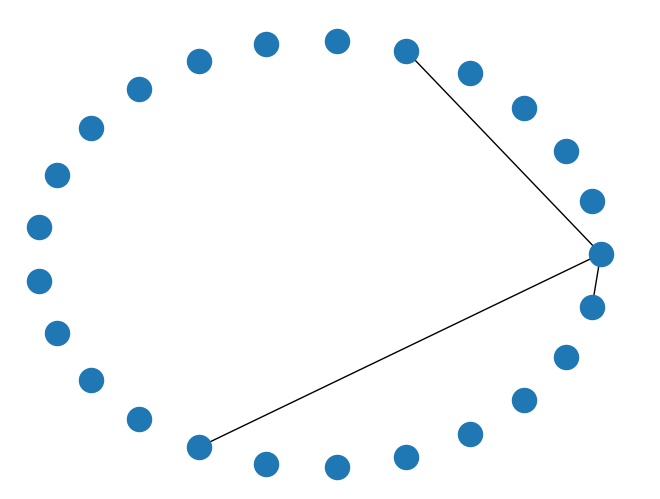

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


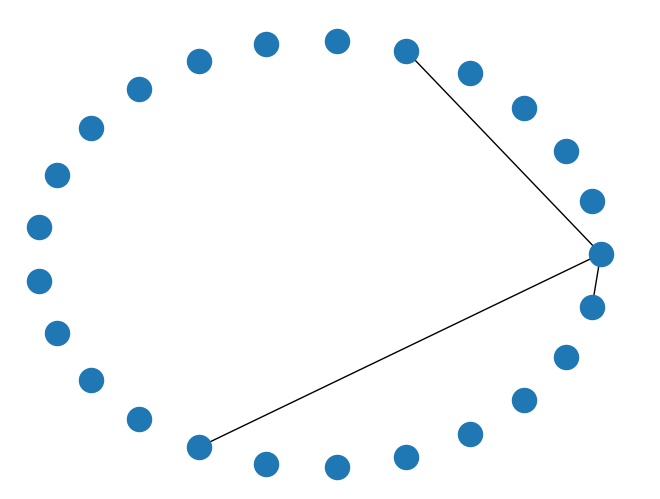

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


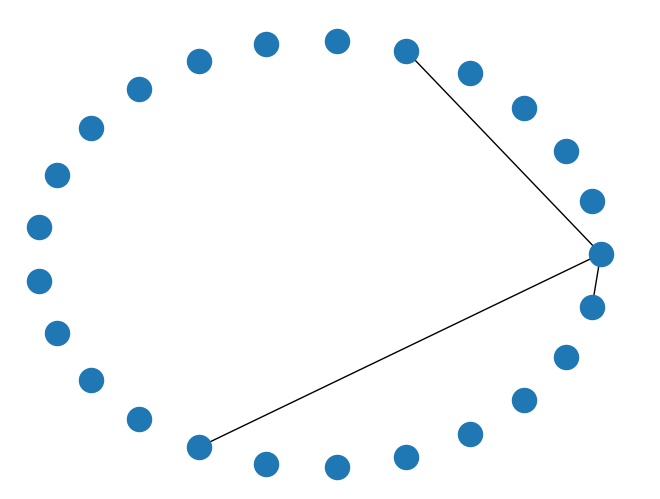

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


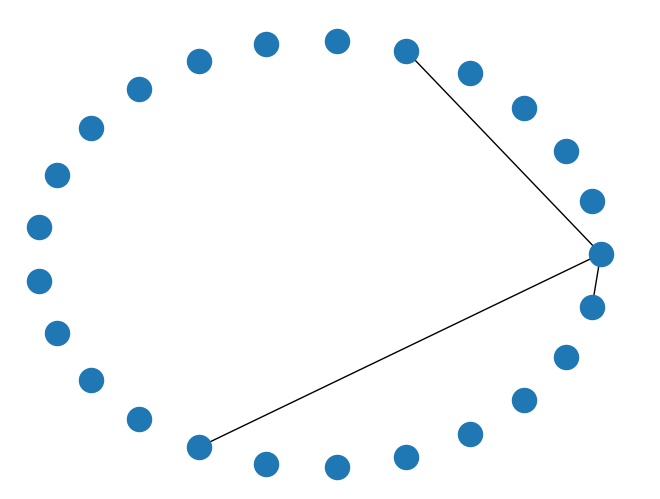

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


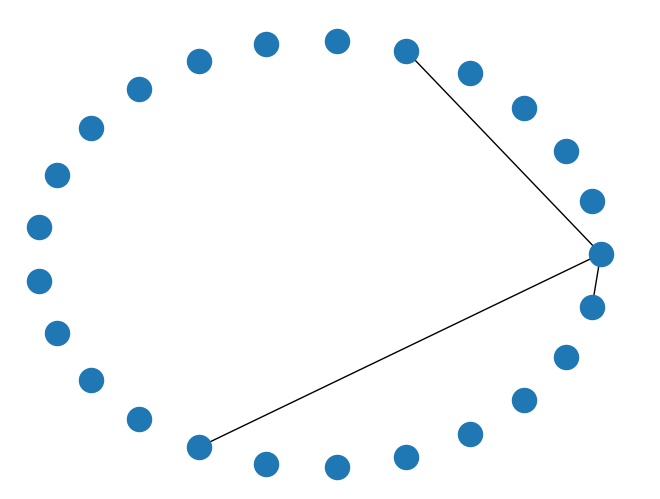

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


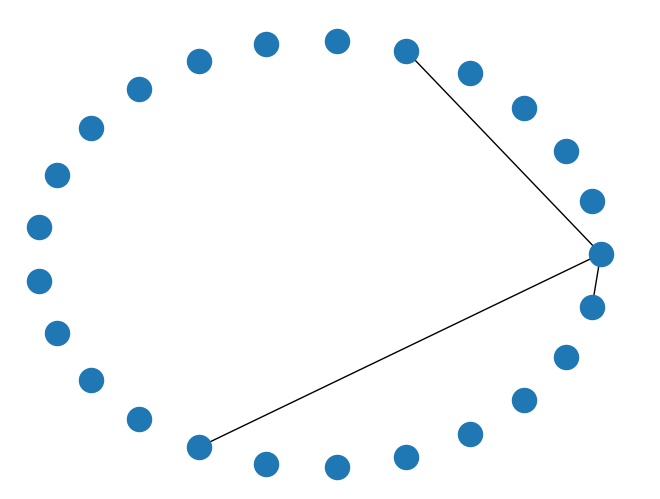

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


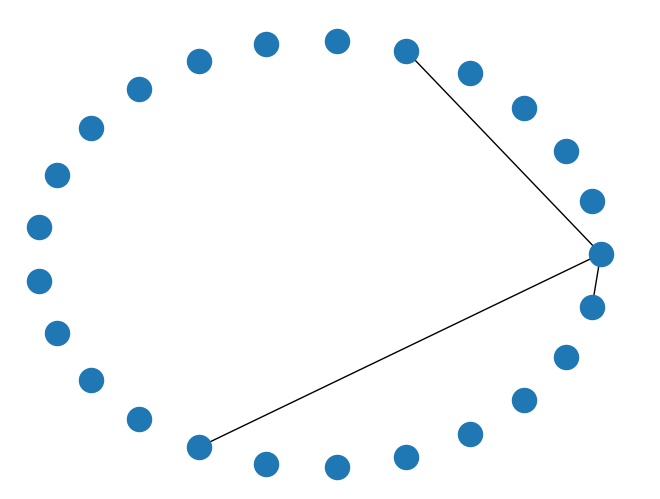

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


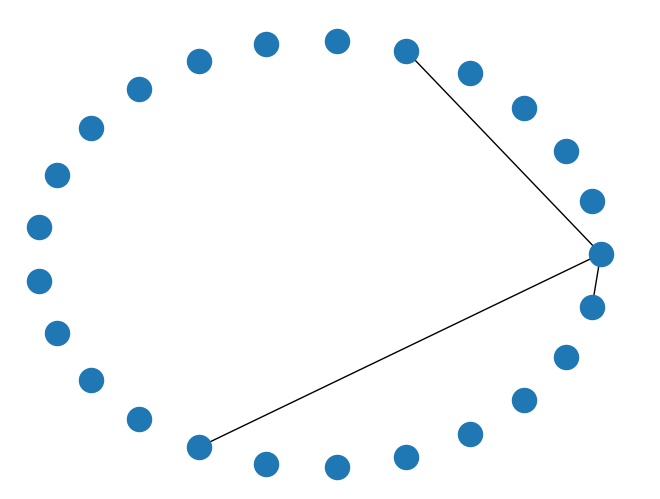

Probailities: [0.00695714580714871, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.0017392864517871776, 0.003478572903574355]
Edges: [(0, 17), (0, 24), (5, 0)]


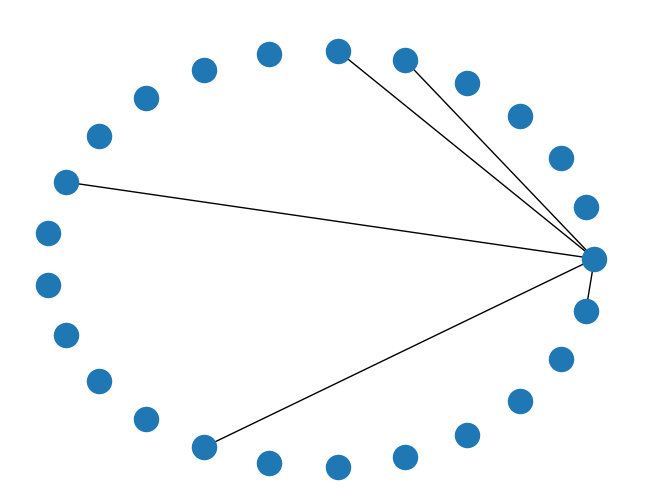

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


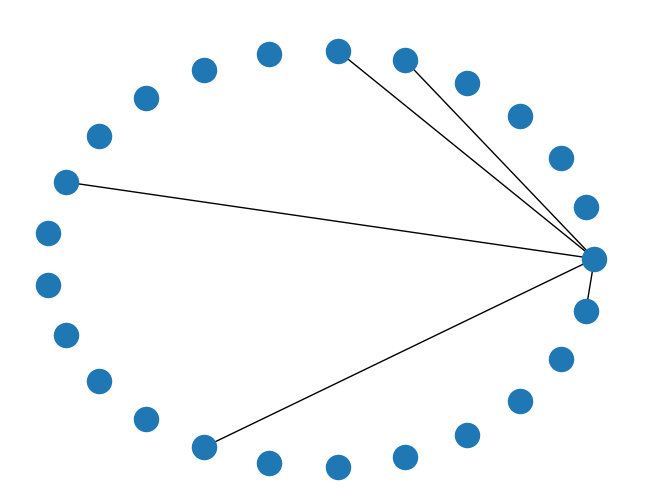

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


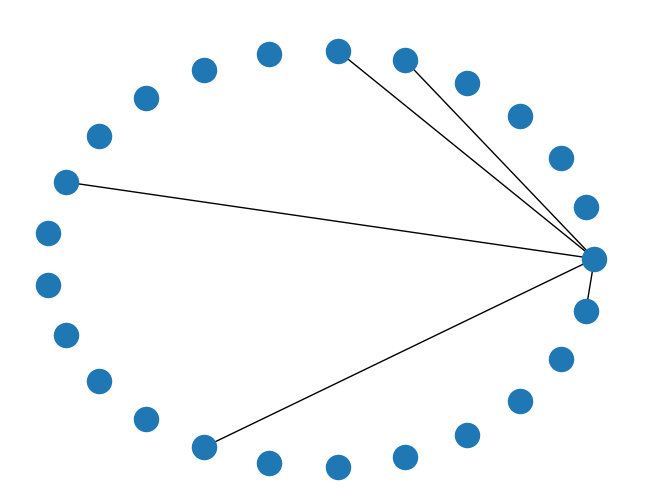

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


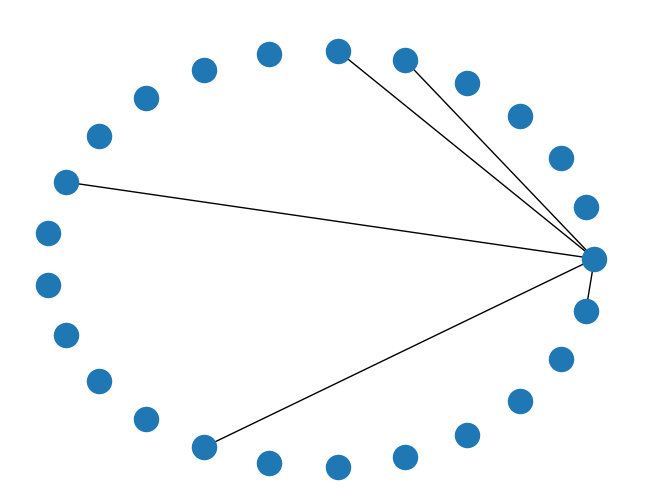

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


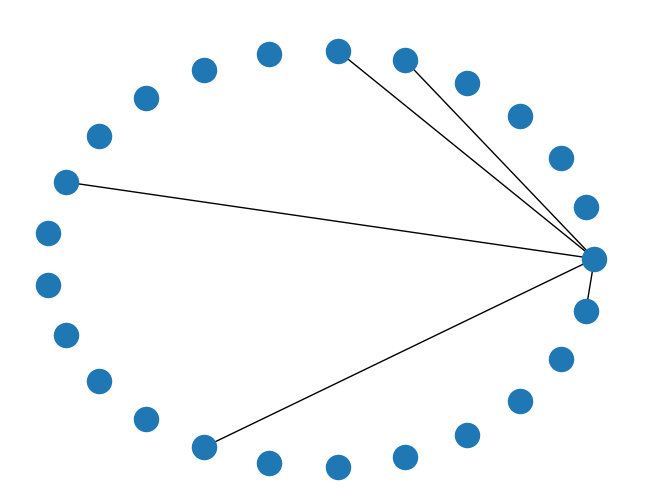

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


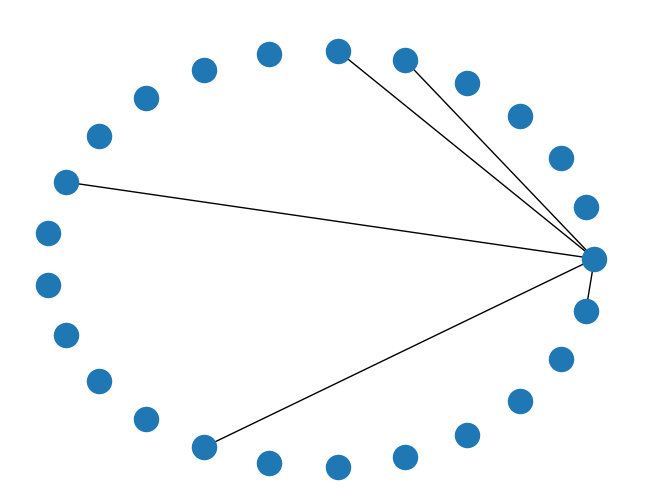

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


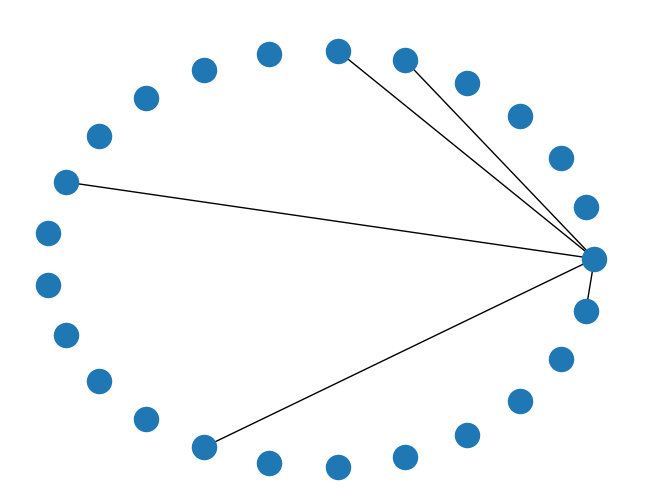

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


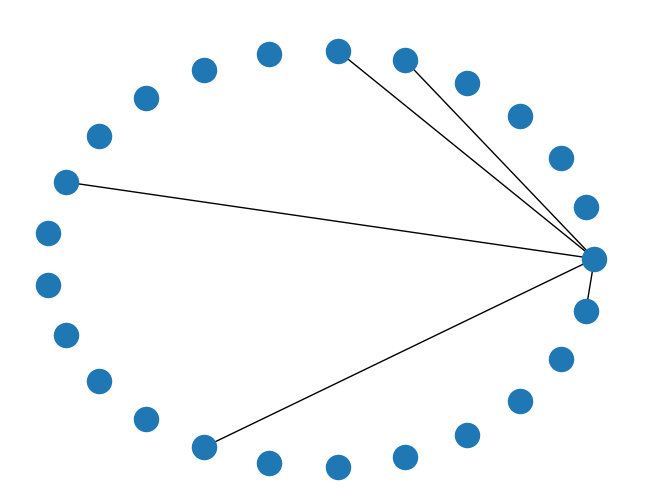

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


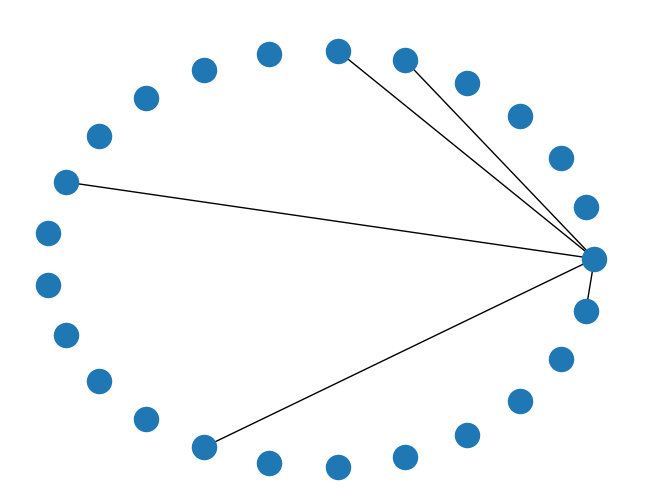

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


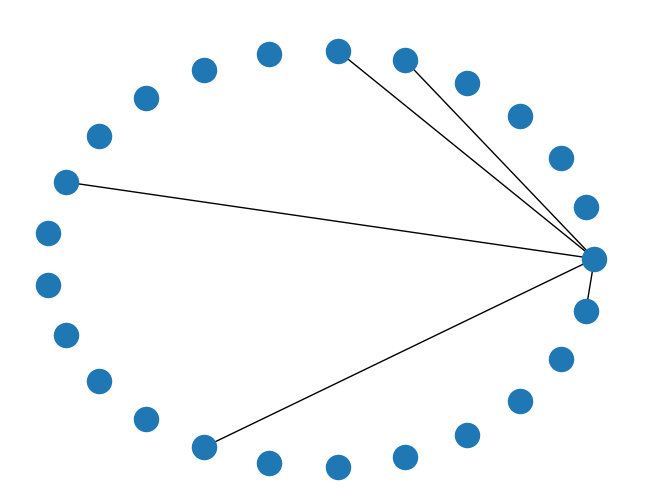

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


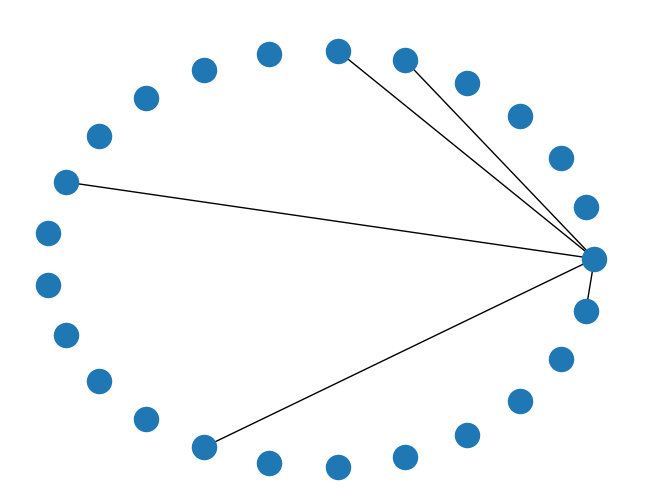

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


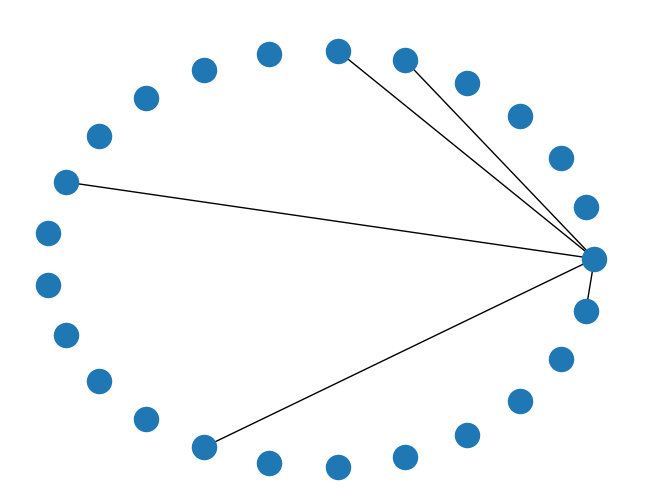

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


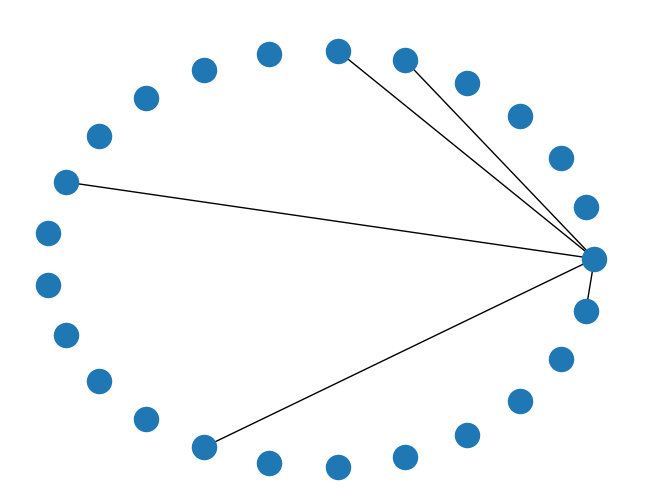

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


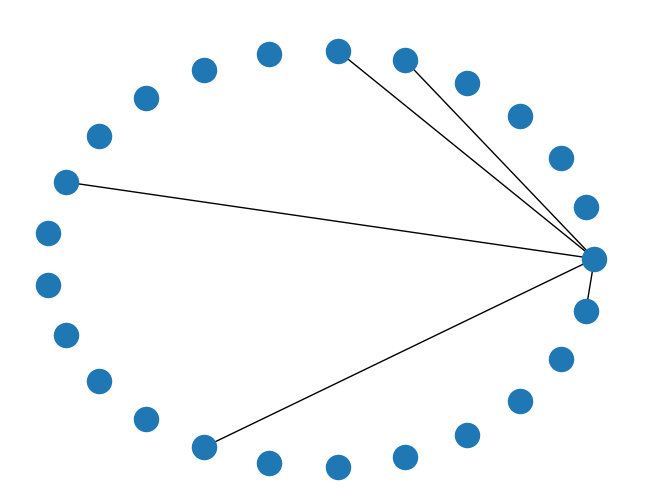

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


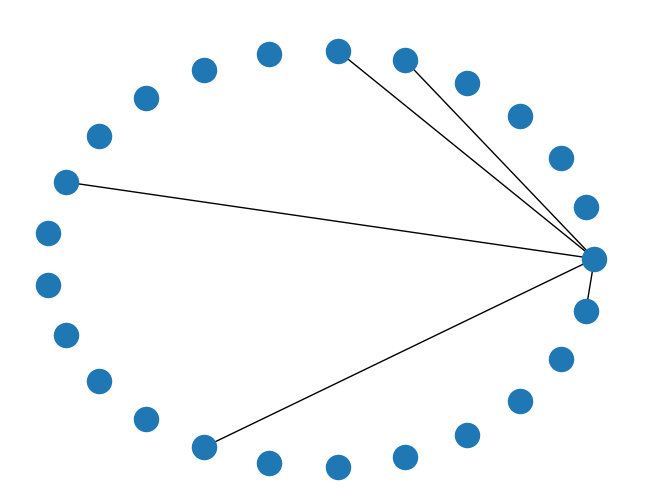

Probailities: [0.01198492115738486, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.0019974868595641435, 0.003994973719128287]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0)]


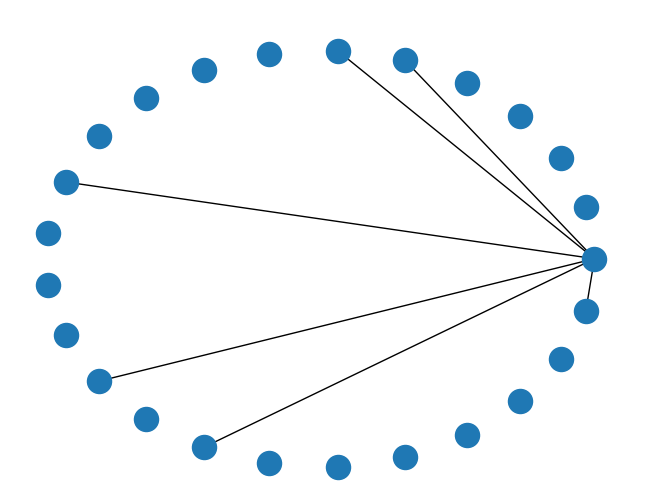

Probailities: [0.05176663783788482, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0)]


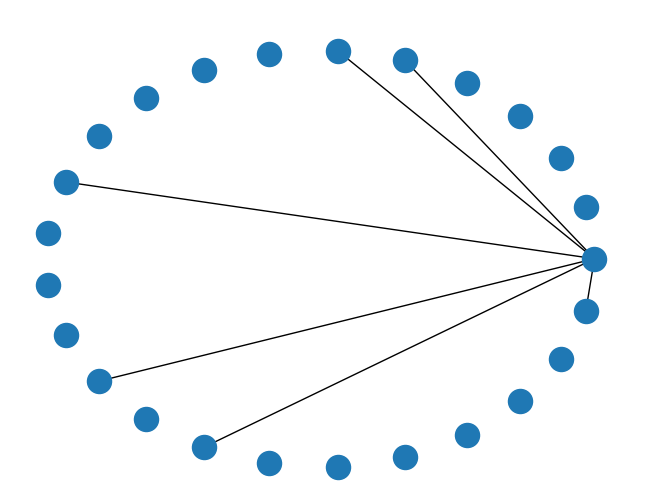

Probailities: [0.05176663783788482, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0)]


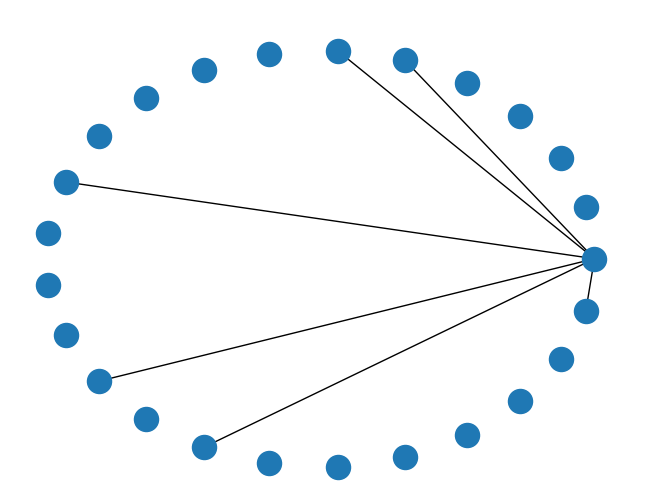

Probailities: [0.05176663783788482, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0)]


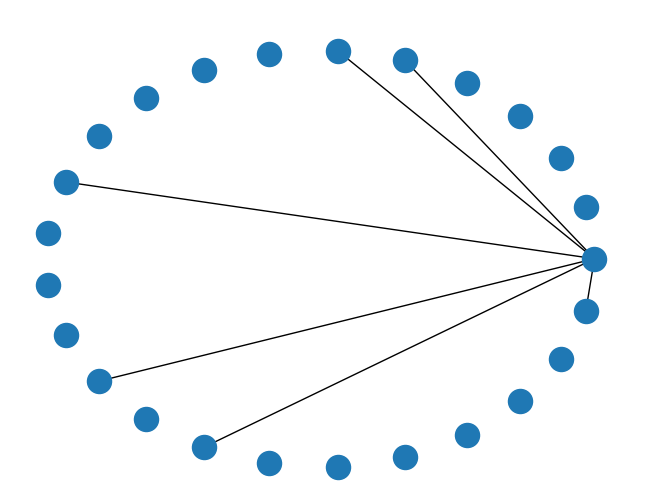

Probailities: [0.05176663783788482, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0)]


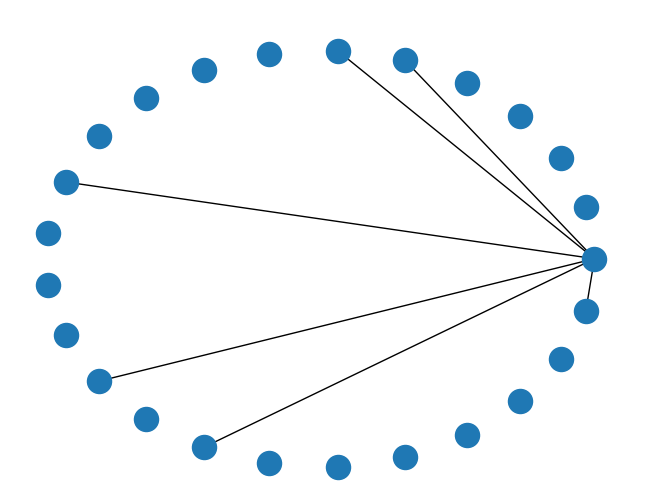

Probailities: [0.05176663783788482, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.01479046795368138, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.00739523397684069, 0.01479046795368138]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0)]


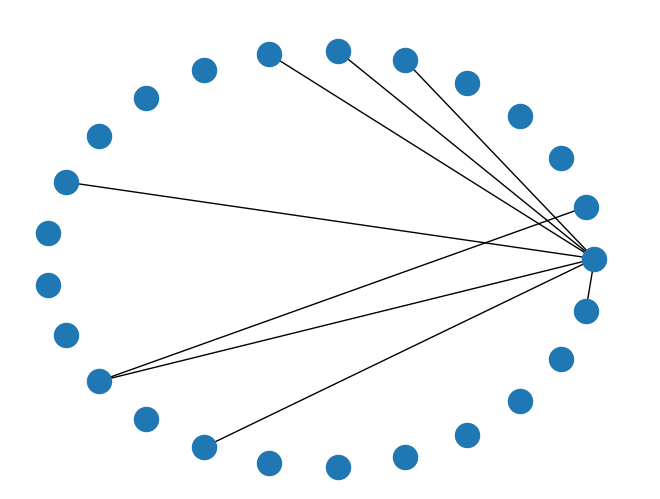

Probailities: [0.07399616670788674, 0.018499041676971684, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.018499041676971684, 0.018499041676971684, 0.018499041676971684, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.018499041676971684, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.02774856251545753, 0.009249520838485842, 0.018499041676971684, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.009249520838485842, 0.018499041676971684]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1)]


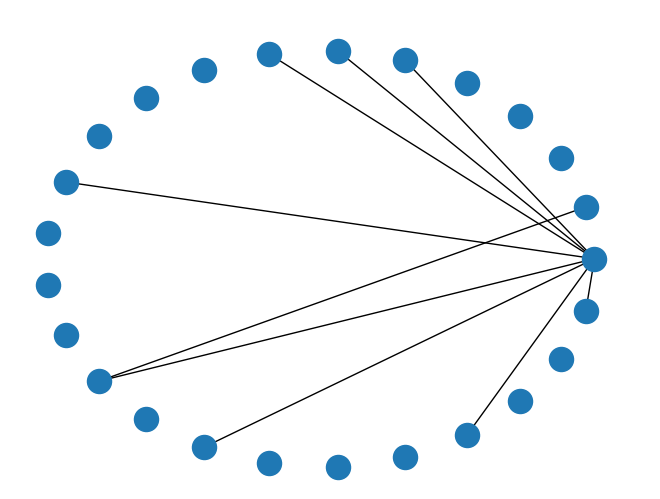

Probailities: [0.08218482638480941, 0.01826329475217987, 0.009131647376089935, 0.009131647376089935, 0.009131647376089935, 0.01826329475217987, 0.01826329475217987, 0.01826329475217987, 0.009131647376089935, 0.009131647376089935, 0.009131647376089935, 0.01826329475217987, 0.009131647376089935, 0.009131647376089935, 0.009131647376089935, 0.027394942128269806, 0.009131647376089935, 0.01826329475217987, 0.009131647376089935, 0.009131647376089935, 0.009131647376089935, 0.01826329475217987, 0.009131647376089935, 0.009131647376089935, 0.01826329475217987]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0)]


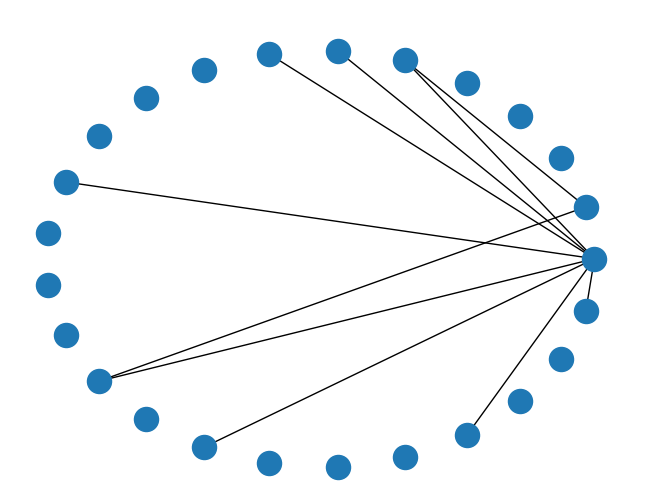

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


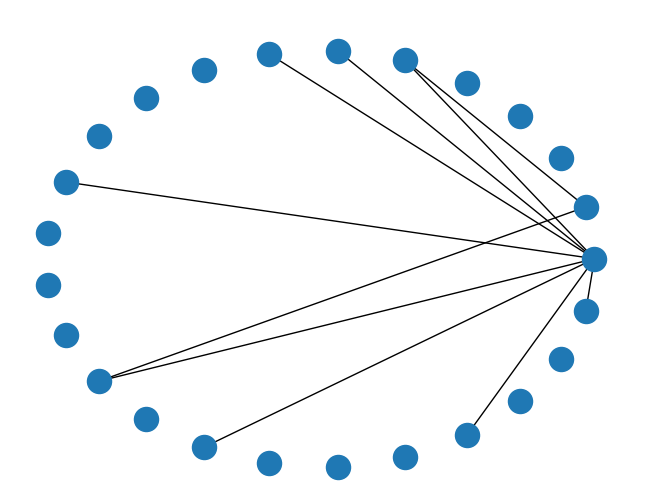

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


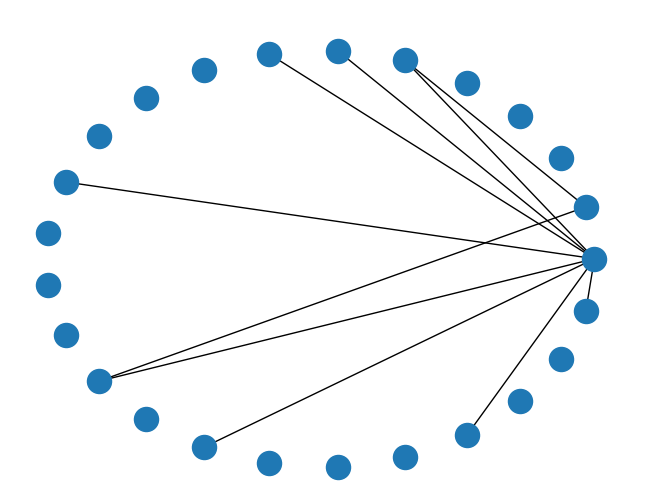

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


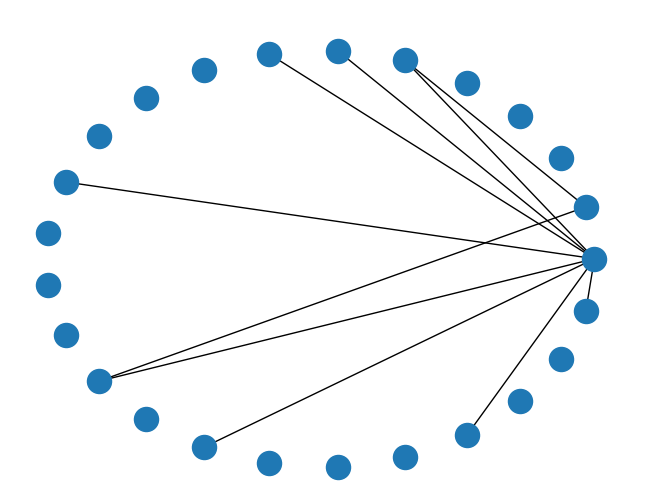

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


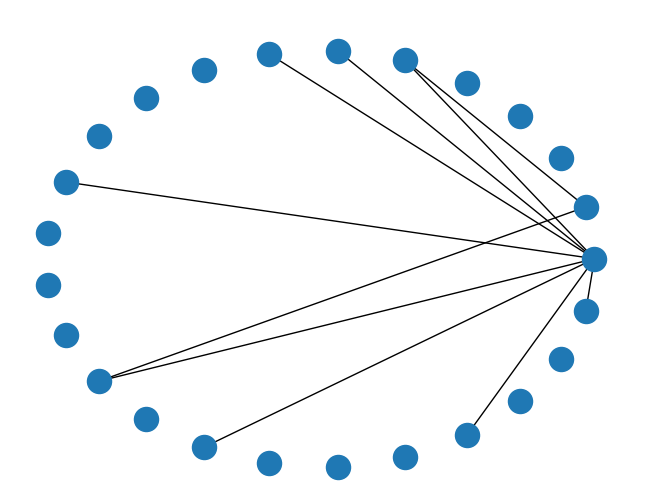

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


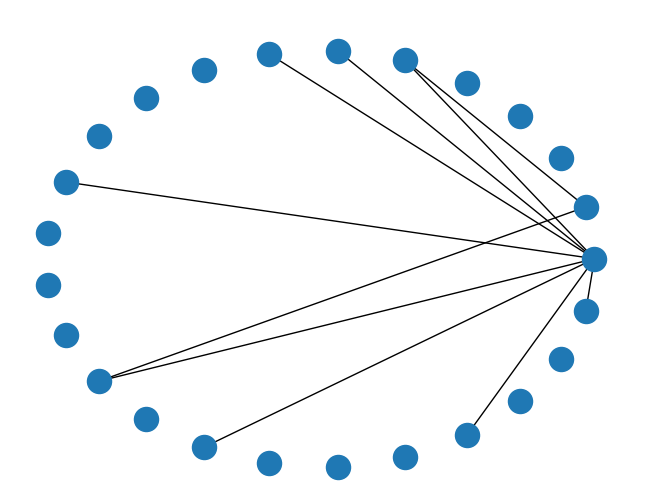

Probailities: [0.08204658802749819, 0.02734886267583273, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.01823257511722182, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.02734886267583273, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182, 0.00911628755861091, 0.00911628755861091, 0.01823257511722182]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1)]


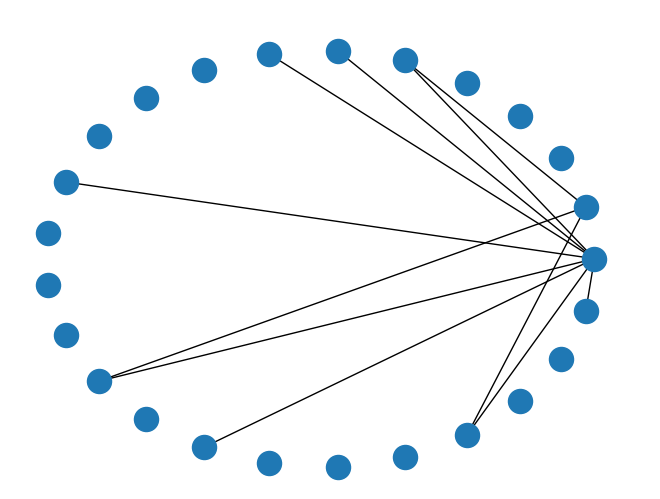

Probailities: [0.13519463142170413, 0.06008650285409072, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.03004325142704536, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1)]


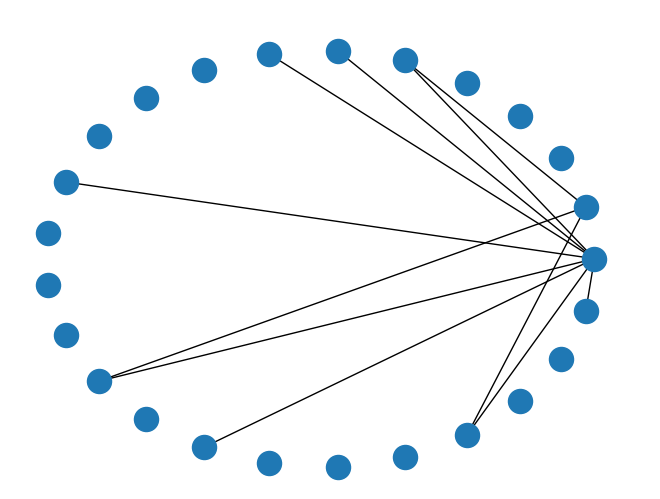

Probailities: [0.13519463142170413, 0.06008650285409072, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.03004325142704536, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1)]


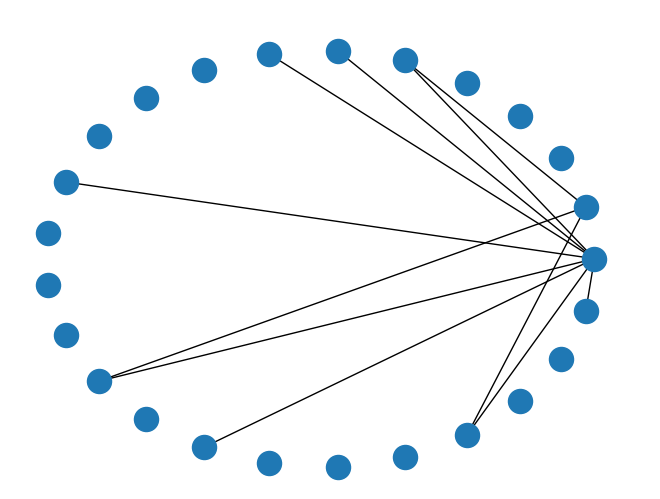

Probailities: [0.13519463142170413, 0.06008650285409072, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.03004325142704536, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1)]


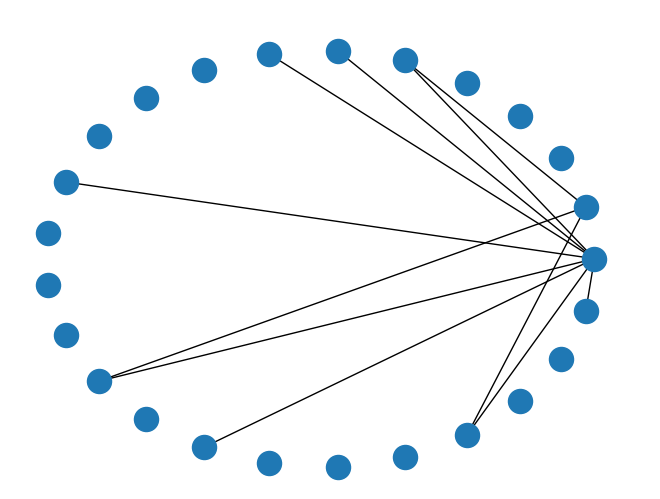

Probailities: [0.13519463142170413, 0.06008650285409072, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.03004325142704536, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.03004325142704536, 0.01502162571352268, 0.01502162571352268, 0.01502162571352268, 0.04506487714056804, 0.01502162571352268, 0.01502162571352268, 0.03004325142704536]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1)]


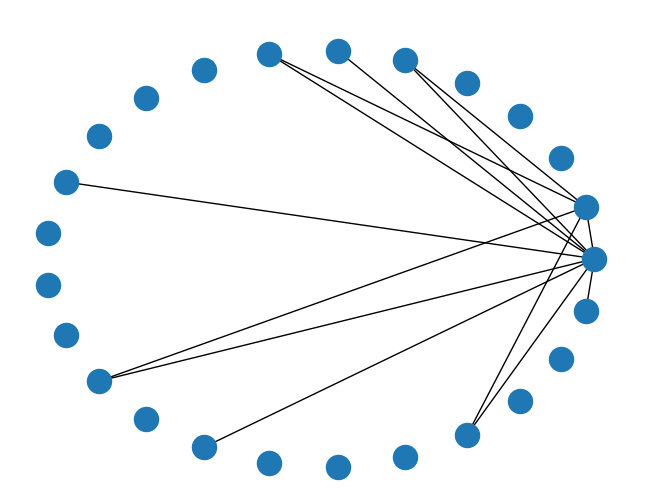

Probailities: [0.18967902850451165, 0.113807417102707, 0.018967902850451166, 0.018967902850451166, 0.018967902850451166, 0.0569037085513535, 0.03793580570090233, 0.0569037085513535, 0.018967902850451166, 0.018967902850451166, 0.018967902850451166, 0.03793580570090233, 0.018967902850451166, 0.018967902850451166, 0.018967902850451166, 0.0569037085513535, 0.018967902850451166, 0.03793580570090233, 0.018967902850451166, 0.018967902850451166, 0.018967902850451166, 0.0569037085513535, 0.018967902850451166, 0.018967902850451166, 0.03793580570090233]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1)]


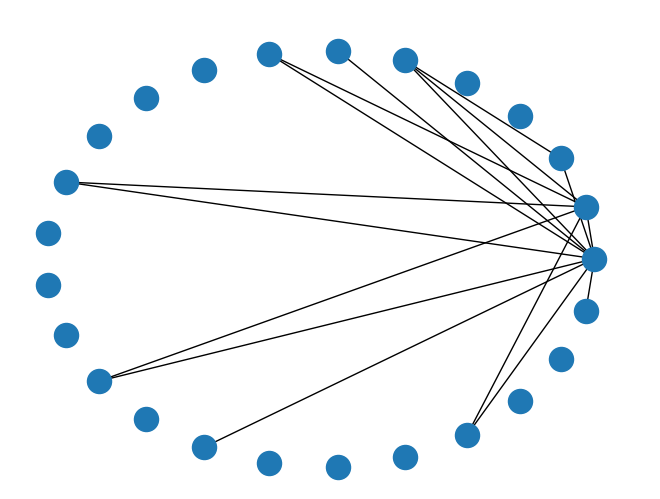

Probailities: [0.1883633488729012, 0.11986758564639169, 0.051371822419882154, 0.017123940806627384, 0.017123940806627384, 0.06849576322650953, 0.03424788161325477, 0.051371822419882154, 0.017123940806627384, 0.017123940806627384, 0.017123940806627384, 0.051371822419882154, 0.017123940806627384, 0.017123940806627384, 0.017123940806627384, 0.051371822419882154, 0.017123940806627384, 0.03424788161325477, 0.017123940806627384, 0.017123940806627384, 0.017123940806627384, 0.051371822419882154, 0.017123940806627384, 0.017123940806627384, 0.03424788161325477]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1)]


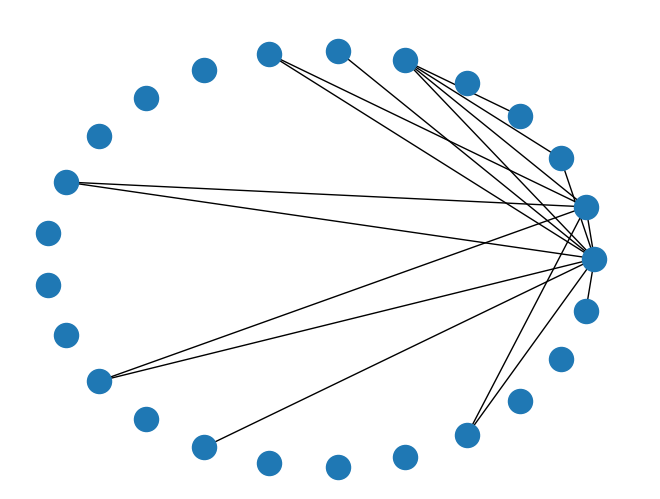

Probailities: [0.19596426169283443, 0.12470453016816736, 0.053444798643500296, 0.03562986576233353, 0.017814932881166767, 0.08907466440583382, 0.03562986576233353, 0.053444798643500296, 0.017814932881166767, 0.017814932881166767, 0.017814932881166767, 0.053444798643500296, 0.017814932881166767, 0.017814932881166767, 0.017814932881166767, 0.053444798643500296, 0.017814932881166767, 0.03562986576233353, 0.017814932881166767, 0.017814932881166767, 0.017814932881166767, 0.053444798643500296, 0.017814932881166767, 0.017814932881166767, 0.03562986576233353]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3)]


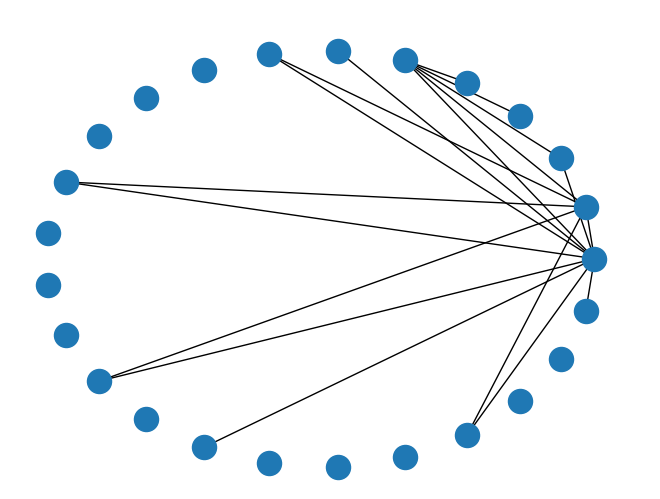

Probailities: [0.20453977455006658, 0.13016167471367873, 0.05578357487729089, 0.037189049918193925, 0.037189049918193925, 0.11156714975458178, 0.037189049918193925, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.037189049918193925, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.037189049918193925]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4)]


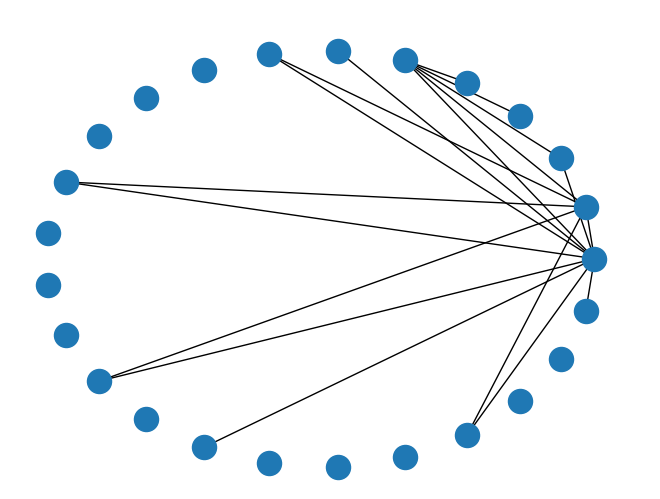

Probailities: [0.20453977455006658, 0.13016167471367873, 0.05578357487729089, 0.037189049918193925, 0.037189049918193925, 0.11156714975458178, 0.037189049918193925, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.037189049918193925, 0.018594524959096963, 0.018594524959096963, 0.018594524959096963, 0.05578357487729089, 0.018594524959096963, 0.018594524959096963, 0.037189049918193925]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4)]


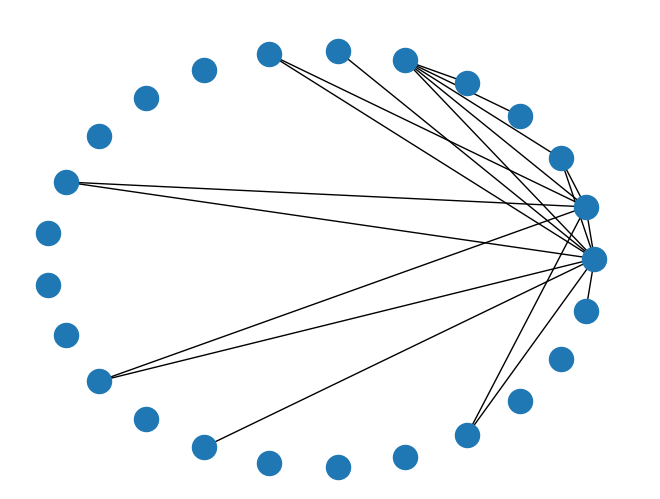

Probailities: [0.23625665130813436, 0.17182301913318862, 0.08591150956659431, 0.042955754783297155, 0.042955754783297155, 0.12886726434989149, 0.042955754783297155, 0.06443363217494574, 0.021477877391648578, 0.021477877391648578, 0.021477877391648578, 0.06443363217494574, 0.021477877391648578, 0.021477877391648578, 0.021477877391648578, 0.06443363217494574, 0.021477877391648578, 0.042955754783297155, 0.021477877391648578, 0.021477877391648578, 0.021477877391648578, 0.06443363217494574, 0.021477877391648578, 0.021477877391648578, 0.042955754783297155]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2)]


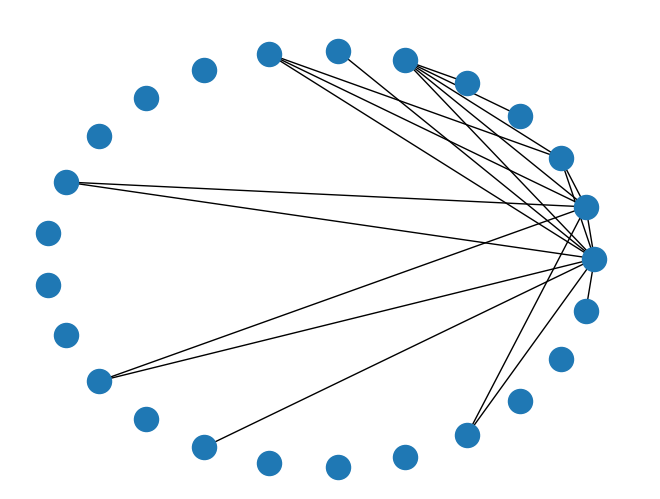

Probailities: [0.2479701309237928, 0.18034191339912203, 0.11271369587445126, 0.04508547834978051, 0.04508547834978051, 0.1352564350493415, 0.04508547834978051, 0.09017095669956102, 0.022542739174890254, 0.022542739174890254, 0.022542739174890254, 0.06762821752467076, 0.022542739174890254, 0.022542739174890254, 0.022542739174890254, 0.06762821752467076, 0.022542739174890254, 0.04508547834978051, 0.022542739174890254, 0.022542739174890254, 0.022542739174890254, 0.06762821752467076, 0.022542739174890254, 0.022542739174890254, 0.04508547834978051]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2)]


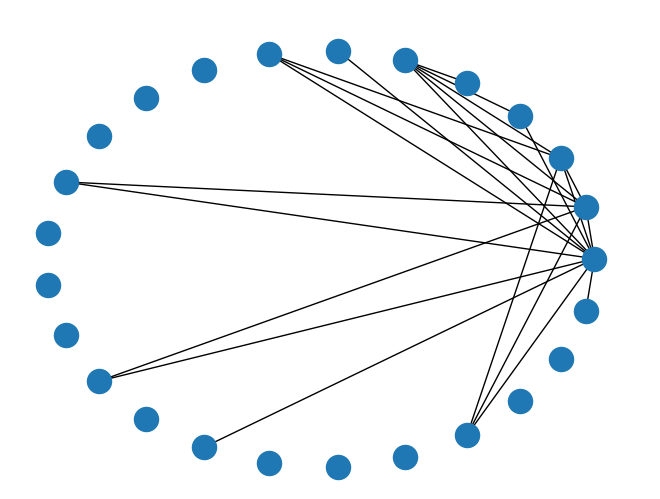

Probailities: [0.271952998848007, 0.18130199923200468, 0.1359764994240035, 0.06798824971200175, 0.04532549980800117, 0.1359764994240035, 0.04532549980800117, 0.09065099961600234, 0.022662749904000586, 0.022662749904000586, 0.022662749904000586, 0.06798824971200175, 0.022662749904000586, 0.022662749904000586, 0.022662749904000586, 0.06798824971200175, 0.022662749904000586, 0.04532549980800117, 0.022662749904000586, 0.022662749904000586, 0.022662749904000586, 0.09065099961600234, 0.022662749904000586, 0.022662749904000586, 0.04532549980800117]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2)]


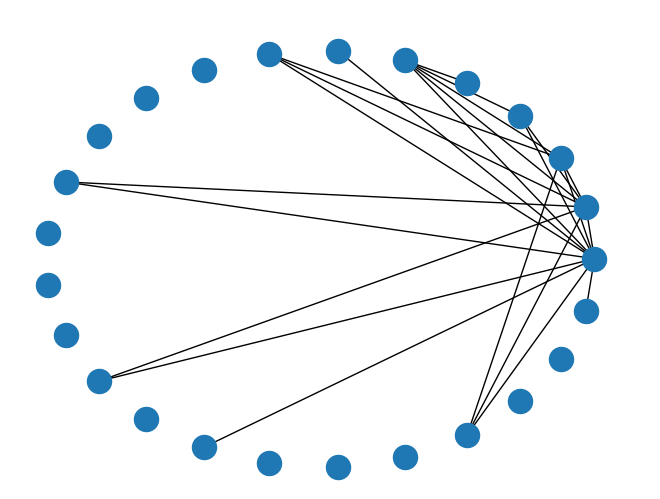

Probailities: [0.28730493444479605, 0.21547870083359705, 0.14365246722239802, 0.09576831148159869, 0.04788415574079934, 0.14365246722239802, 0.04788415574079934, 0.09576831148159869, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.07182623361119901, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.07182623361119901, 0.02394207787039967, 0.04788415574079934, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.09576831148159869, 0.02394207787039967, 0.02394207787039967, 0.04788415574079934]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3)]


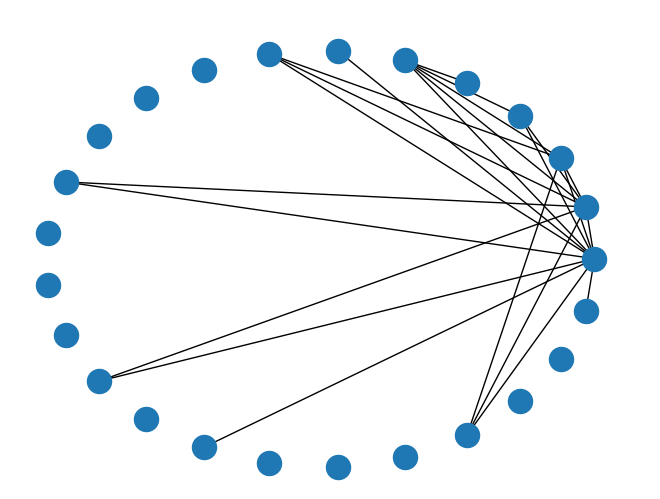

Probailities: [0.28730493444479605, 0.21547870083359705, 0.14365246722239802, 0.09576831148159869, 0.04788415574079934, 0.14365246722239802, 0.04788415574079934, 0.09576831148159869, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.07182623361119901, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.07182623361119901, 0.02394207787039967, 0.04788415574079934, 0.02394207787039967, 0.02394207787039967, 0.02394207787039967, 0.09576831148159869, 0.02394207787039967, 0.02394207787039967, 0.04788415574079934]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3)]


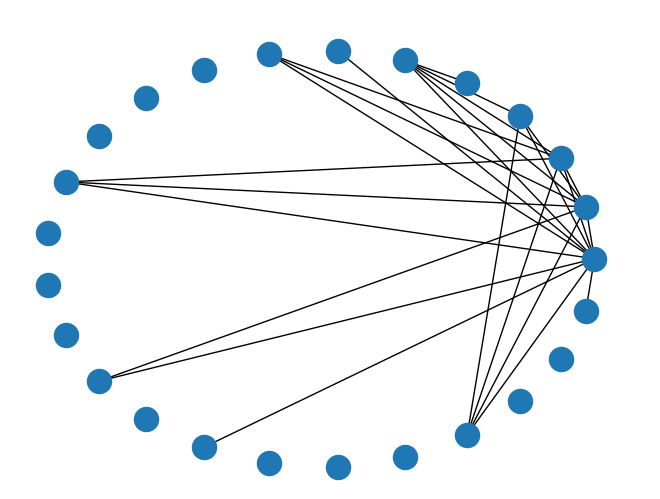

Probailities: [0.3223590898505152, 0.2417693173878864, 0.18804280241280055, 0.13431628743771468, 0.05372651497508586, 0.1611795449252576, 0.05372651497508586, 0.10745302995017172, 0.02686325748754293, 0.02686325748754293, 0.02686325748754293, 0.10745302995017172, 0.02686325748754293, 0.02686325748754293, 0.02686325748754293, 0.0805897724626288, 0.02686325748754293, 0.05372651497508586, 0.02686325748754293, 0.02686325748754293, 0.02686325748754293, 0.13431628743771468, 0.02686325748754293, 0.02686325748754293, 0.05372651497508586]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3)]


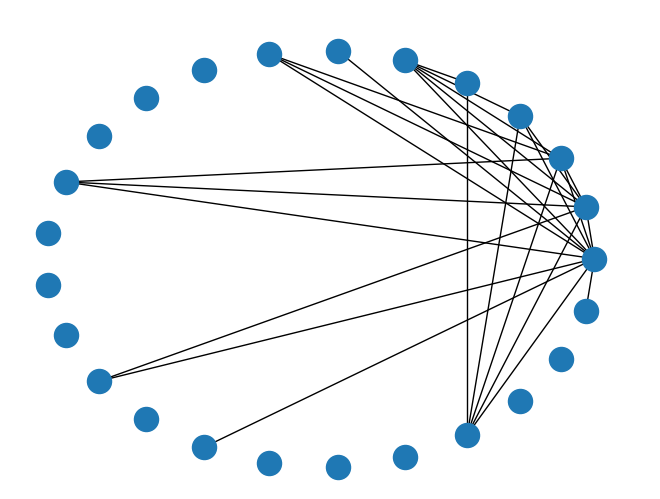

Probailities: [0.3422699760251976, 0.25670248201889817, 0.1996574860146986, 0.142612490010499, 0.0855674940062994, 0.1711349880125988, 0.0570449960041996, 0.1140899920083992, 0.0285224980020998, 0.0285224980020998, 0.0285224980020998, 0.1140899920083992, 0.0285224980020998, 0.0285224980020998, 0.0285224980020998, 0.0855674940062994, 0.0285224980020998, 0.0570449960041996, 0.0285224980020998, 0.0285224980020998, 0.0285224980020998, 0.1711349880125988, 0.0285224980020998, 0.0285224980020998, 0.0570449960041996]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4)]


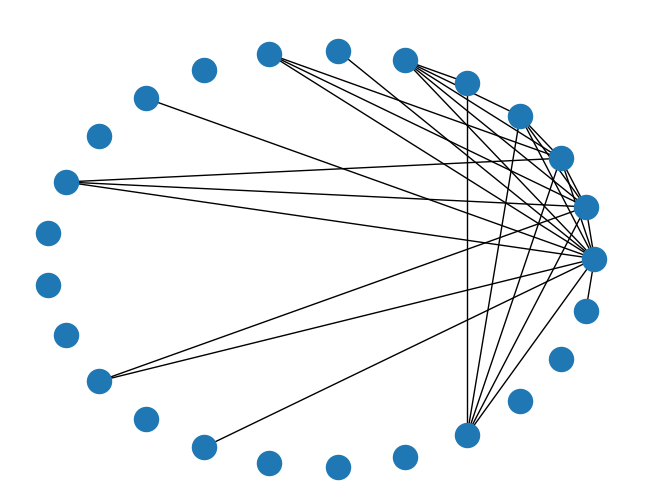

Probailities: [0.38042276836306155, 0.2633696088667349, 0.23410631899265325, 0.17557973924448994, 0.08778986962224497, 0.17557973924448994, 0.05852657974816331, 0.11705315949632662, 0.029263289874081656, 0.05852657974816331, 0.029263289874081656, 0.11705315949632662, 0.029263289874081656, 0.029263289874081656, 0.029263289874081656, 0.08778986962224497, 0.029263289874081656, 0.05852657974816331, 0.029263289874081656, 0.029263289874081656, 0.029263289874081656, 0.17557973924448994, 0.029263289874081656, 0.029263289874081656, 0.05852657974816331]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0)]


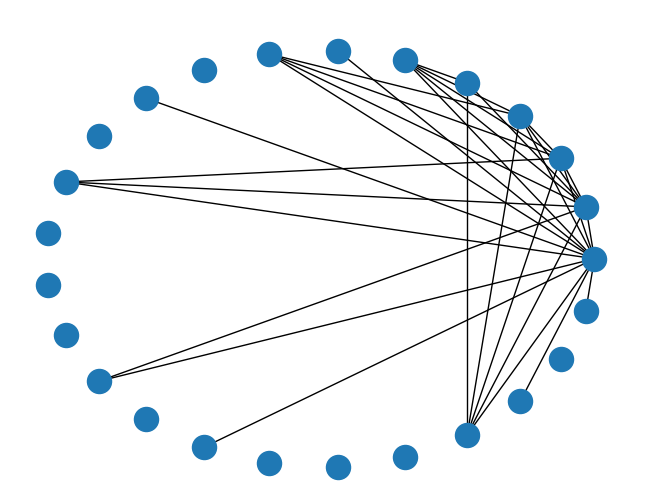

Probailities: [0.4089969489429428, 0.2921406778163877, 0.23371254225311017, 0.2044984744714714, 0.11685627112655508, 0.17528440668983264, 0.05842813556327754, 0.14607033890819385, 0.02921406778163877, 0.05842813556327754, 0.02921406778163877, 0.11685627112655508, 0.02921406778163877, 0.02921406778163877, 0.02921406778163877, 0.08764220334491632, 0.02921406778163877, 0.05842813556327754, 0.02921406778163877, 0.02921406778163877, 0.02921406778163877, 0.17528440668983264, 0.05842813556327754, 0.02921406778163877, 0.05842813556327754]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0)]


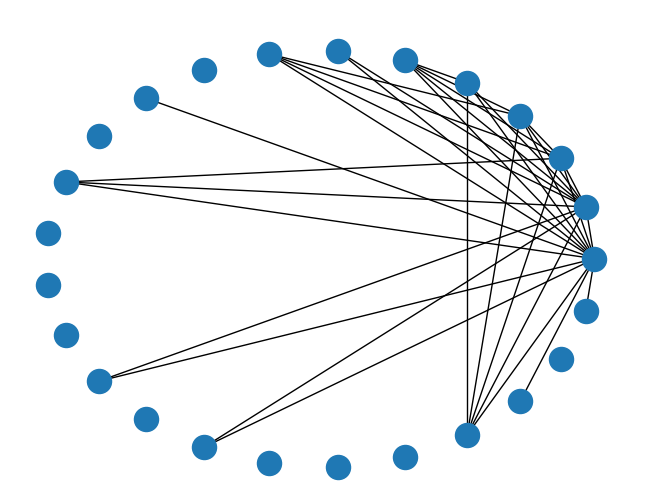

Probailities: [0.4414782652493855, 0.3531826121995084, 0.2354550747996723, 0.20602319044971326, 0.14715942174979518, 0.1765913060997542, 0.0882956530498771, 0.14715942174979518, 0.029431884349959036, 0.05886376869991807, 0.029431884349959036, 0.11772753739983614, 0.029431884349959036, 0.029431884349959036, 0.029431884349959036, 0.0882956530498771, 0.029431884349959036, 0.0882956530498771, 0.029431884349959036, 0.029431884349959036, 0.029431884349959036, 0.1765913060997542, 0.05886376869991807, 0.029431884349959036, 0.05886376869991807]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1)]


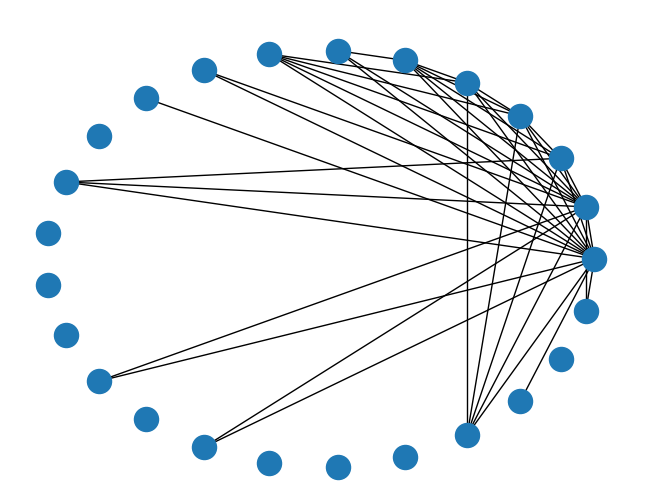

Probailities: [0.44262577465166814, 0.3872975528202096, 0.22131288732583407, 0.22131288732583407, 0.1936487764101048, 0.1936487764101048, 0.11065644366291703, 0.16598466549437554, 0.08299233274718777, 0.05532822183145852, 0.02766411091572926, 0.11065644366291703, 0.02766411091572926, 0.02766411091572926, 0.02766411091572926, 0.08299233274718777, 0.02766411091572926, 0.08299233274718777, 0.02766411091572926, 0.02766411091572926, 0.02766411091572926, 0.16598466549437554, 0.05532822183145852, 0.02766411091572926, 0.08299233274718777]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1)]


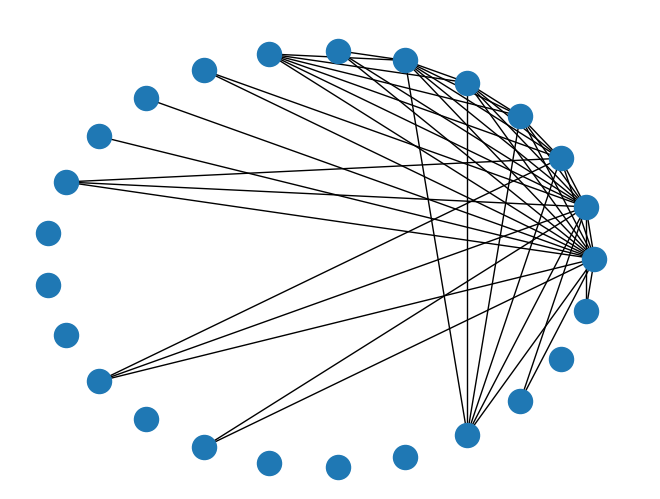

Probailities: [0.4519623789230124, 0.39879033434383443, 0.2658602228958896, 0.21268817831671172, 0.21268817831671172, 0.23927420060630067, 0.10634408915835586, 0.18610215602712277, 0.0797580668687669, 0.05317204457917793, 0.05317204457917793, 0.10634408915835586, 0.026586022289588965, 0.026586022289588965, 0.026586022289588965, 0.10634408915835586, 0.026586022289588965, 0.0797580668687669, 0.026586022289588965, 0.026586022289588965, 0.026586022289588965, 0.18610215602712277, 0.0797580668687669, 0.026586022289588965, 0.0797580668687669]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1)]


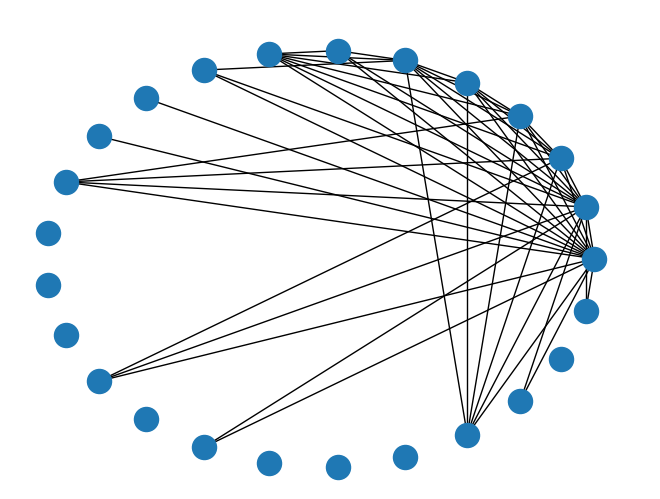

Probailities: [0.46847305510849785, 0.4133585780369099, 0.27557238535793993, 0.24801514682214593, 0.22045790828635195, 0.27557238535793993, 0.13778619267896997, 0.22045790828635195, 0.11022895414317598, 0.05511447707158799, 0.05511447707158799, 0.13778619267896997, 0.027557238535793994, 0.027557238535793994, 0.027557238535793994, 0.11022895414317598, 0.027557238535793994, 0.08267171560738198, 0.027557238535793994, 0.027557238535793994, 0.027557238535793994, 0.19290066975055795, 0.08267171560738198, 0.027557238535793994, 0.08267171560738198]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3)]


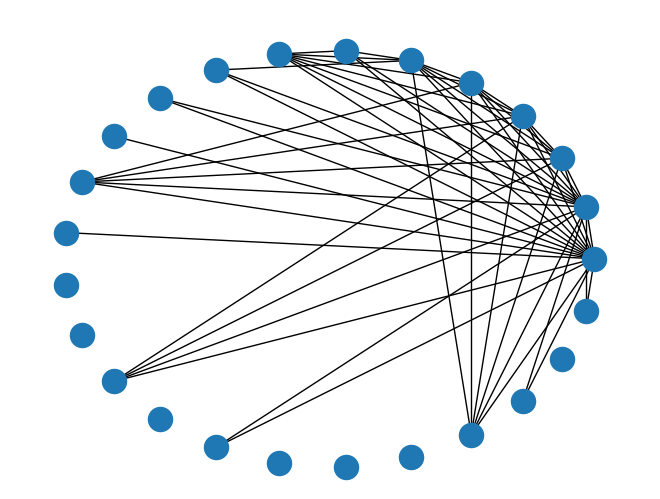

Probailities: [0.5064005801313305, 0.4501338490056271, 0.2813336556285169, 0.2813336556285169, 0.25320029006566525, 0.2813336556285169, 0.14066682781425846, 0.22506692450281354, 0.11253346225140677, 0.08440009668855508, 0.056266731125703386, 0.16880019337711016, 0.056266731125703386, 0.028133365562851693, 0.028133365562851693, 0.14066682781425846, 0.028133365562851693, 0.08440009668855508, 0.028133365562851693, 0.028133365562851693, 0.028133365562851693, 0.19693355893996184, 0.08440009668855508, 0.028133365562851693, 0.08440009668855508]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3)]


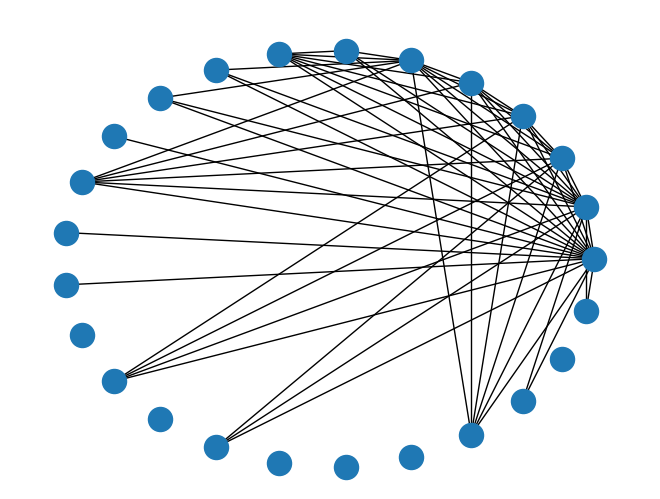

Probailities: [0.5487768781082918, 0.46212789735435095, 0.3177129294311163, 0.2888299358464693, 0.25994694226182247, 0.3465959230157632, 0.14441496792323466, 0.23106394867717547, 0.11553197433858774, 0.11553197433858774, 0.05776598716929387, 0.20218095509252856, 0.05776598716929387, 0.05776598716929387, 0.028882993584646934, 0.14441496792323466, 0.028882993584646934, 0.11553197433858774, 0.028882993584646934, 0.028882993584646934, 0.028882993584646934, 0.20218095509252856, 0.0866489807539408, 0.028882993584646934, 0.0866489807539408]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 1

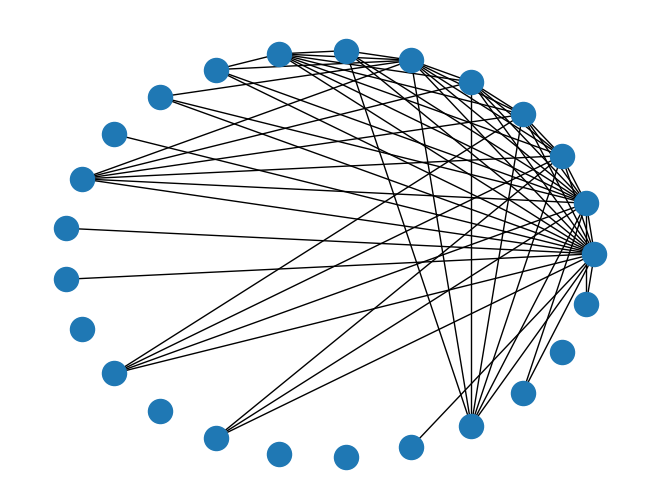

Probailities: [0.6057860197258887, 0.48462881578071104, 0.3331823108492388, 0.3028930098629444, 0.27260370887665, 0.3634716118355333, 0.18173580591776664, 0.27260370887665, 0.1514465049314722, 0.12115720394517776, 0.06057860197258888, 0.21202510690406107, 0.06057860197258888, 0.06057860197258888, 0.03028930098629444, 0.1514465049314722, 0.03028930098629444, 0.12115720394517776, 0.03028930098629444, 0.03028930098629444, 0.06057860197258888, 0.24231440789035552, 0.09086790295888332, 0.03028930098629444, 0.09086790295888332]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), 

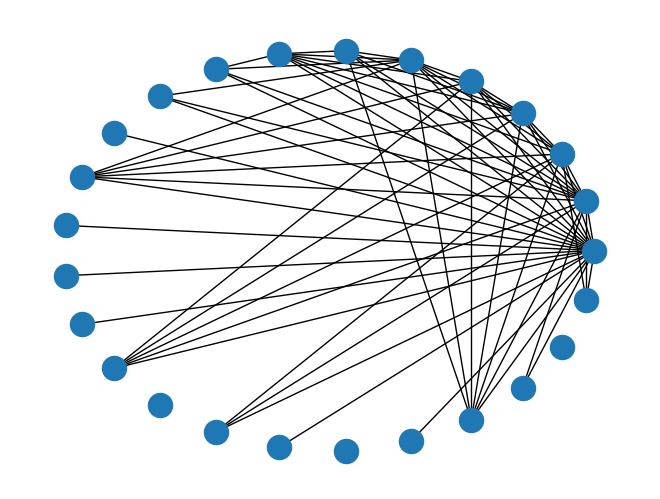

Probailities: [0.6791419907516194, 0.49392144781935954, 0.3704410858645197, 0.3395709953758097, 0.3087009048870997, 0.3704410858645197, 0.2160906334209698, 0.27783081439838975, 0.15435045244354986, 0.12348036195483988, 0.06174018097741994, 0.2160906334209698, 0.06174018097741994, 0.06174018097741994, 0.06174018097741994, 0.18522054293225984, 0.03087009048870997, 0.12348036195483988, 0.06174018097741994, 0.03087009048870997, 0.06174018097741994, 0.24696072390967977, 0.09261027146612992, 0.03087009048870997, 0.12348036195483988]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5,

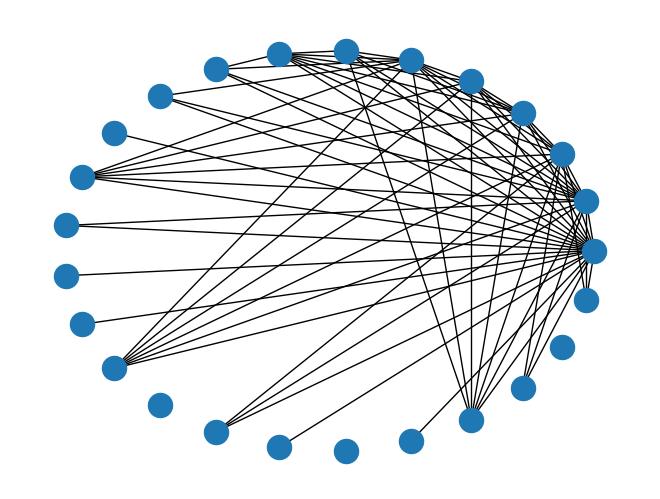

Probailities: [0.716548991112753, 0.5536969476780365, 0.4234153129302632, 0.3582744955563765, 0.3257040868694332, 0.4234153129302632, 0.22799286080860326, 0.2931336781824899, 0.1628520434347166, 0.1302816347477733, 0.06514081737388665, 0.22799286080860326, 0.09771122606082998, 0.06514081737388665, 0.06514081737388665, 0.22799286080860326, 0.032570408686943324, 0.1302816347477733, 0.06514081737388665, 0.032570408686943324, 0.06514081737388665, 0.2605632694955466, 0.1302816347477733, 0.032570408686943324, 0.1302816347477733]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9),

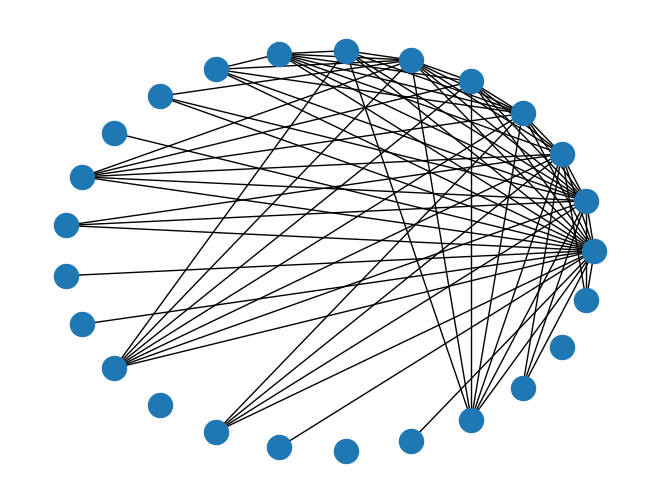

Probailities: [0.7470213785487432, 0.5772437925149378, 0.4753772408946547, 0.4414217236878937, 0.33955517206761054, 0.4414217236878937, 0.2716441376540884, 0.3055996548608495, 0.20373310324056632, 0.1358220688270442, 0.0679110344135221, 0.23768862044732736, 0.1358220688270442, 0.0679110344135221, 0.0679110344135221, 0.2716441376540884, 0.03395551720676105, 0.16977758603380527, 0.0679110344135221, 0.03395551720676105, 0.0679110344135221, 0.2716441376540884, 0.1358220688270442, 0.03395551720676105, 0.1358220688270442]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5

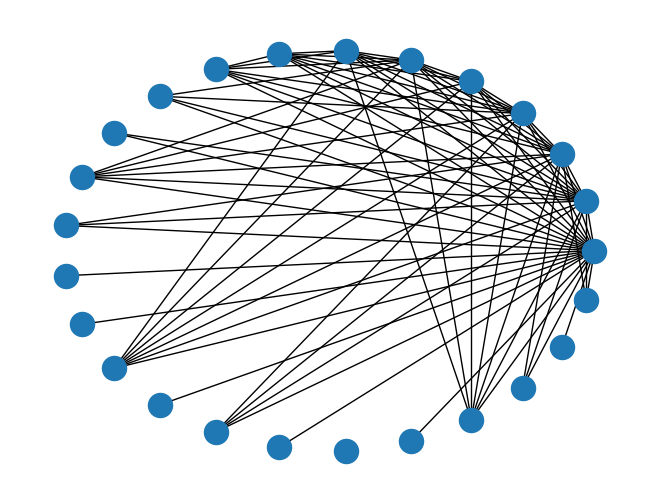

Probailities: [0.8098382678083775, 0.6073787008562832, 0.5398921785389184, 0.47240565622155356, 0.3711758727455064, 0.4386623950628712, 0.3711758727455064, 0.3036893504281416, 0.2699460892694592, 0.16871630579341199, 0.10122978347604719, 0.23620282811077678, 0.1349730446347296, 0.0674865223173648, 0.0674865223173648, 0.2699460892694592, 0.0674865223173648, 0.16871630579341199, 0.0674865223173648, 0.0337432611586824, 0.0674865223173648, 0.2699460892694592, 0.1349730446347296, 0.0674865223173648, 0.1349730446347296]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5),

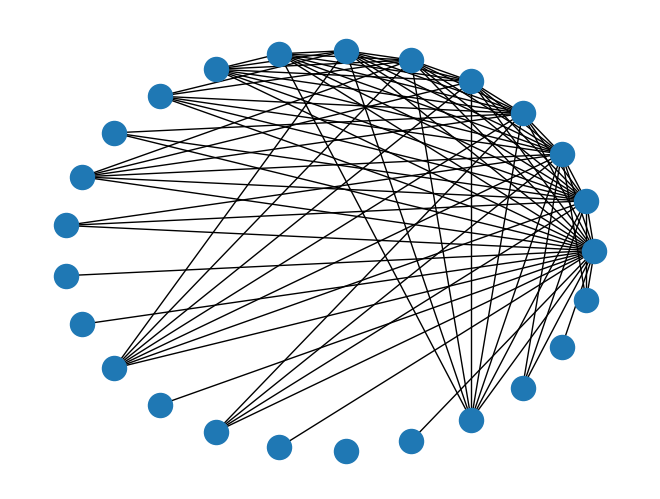

Probailities: [0.8413227593931657, 0.6309920695448743, 0.595936954570159, 0.5258267246207285, 0.42066137969658285, 0.4557164946712981, 0.42066137969658285, 0.3505511497471524, 0.31549603477243715, 0.24538580482300668, 0.14022045989886095, 0.24538580482300668, 0.14022045989886095, 0.07011022994943047, 0.07011022994943047, 0.2804409197977219, 0.07011022994943047, 0.1752755748735762, 0.07011022994943047, 0.03505511497471524, 0.07011022994943047, 0.31549603477243715, 0.14022045989886095, 0.07011022994943047, 0.14022045989886095]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9

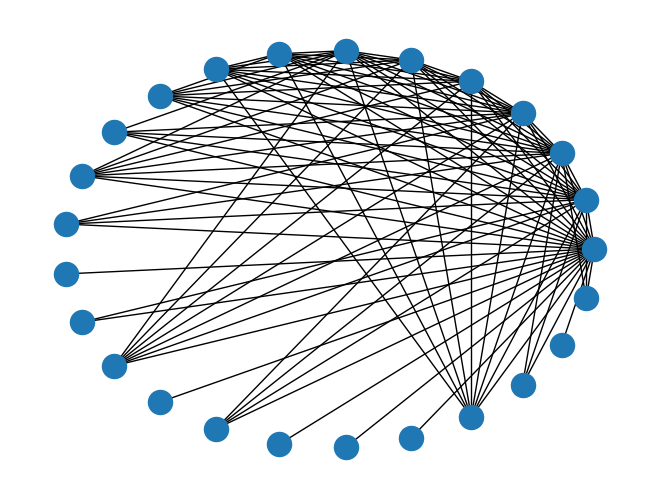

Probailities: [0.8749037696813388, 0.6649268649578174, 0.6299307141705639, 0.5599384125960568, 0.4549499602342961, 0.4549499602342961, 0.48994611102154967, 0.38495765865978904, 0.3499615078725355, 0.31496535708528195, 0.2099769047235213, 0.2799692062980284, 0.17498075393626775, 0.0699923015745071, 0.10498845236176065, 0.2799692062980284, 0.0699923015745071, 0.17498075393626775, 0.0699923015745071, 0.0699923015745071, 0.0699923015745071, 0.3499615078725355, 0.1399846031490142, 0.0699923015745071, 0.1399846031490142]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5)

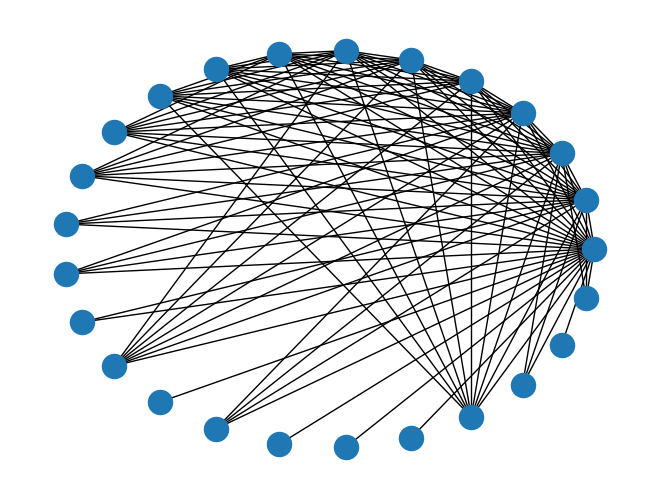

Probailities: [0.8987949653942461, 0.7190359723153968, 0.683084173699627, 0.6111805764680873, 0.5033251806207778, 0.5033251806207778, 0.5033251806207778, 0.4314215833892381, 0.3595179861576984, 0.3595179861576984, 0.3235661875419286, 0.28761438892615876, 0.1797589930788492, 0.1797589930788492, 0.10785539584730952, 0.28761438892615876, 0.07190359723153969, 0.1797589930788492, 0.07190359723153969, 0.07190359723153969, 0.07190359723153969, 0.3954697847734683, 0.14380719446307938, 0.07190359723153969, 0.14380719446307938]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11,

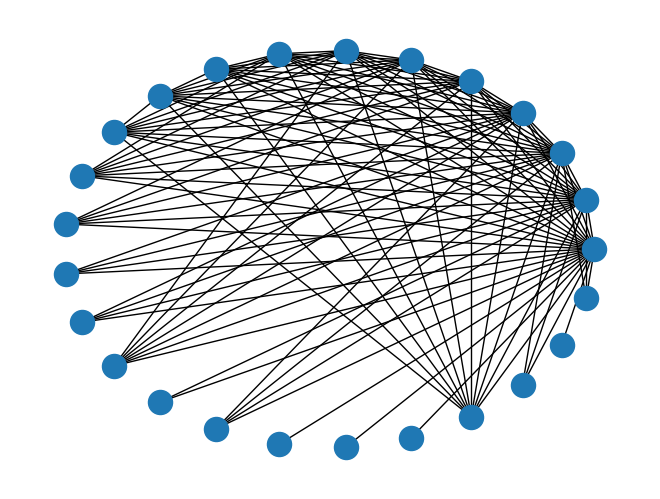

Probailities: [0.910959296595351, 0.7652058091400948, 0.7287674372762808, 0.6558906935486528, 0.5465755779572106, 0.5465755779572106, 0.5101372060933965, 0.47369883422958253, 0.40082209050195444, 0.43726046236576854, 0.40082209050195444, 0.3279453467743264, 0.25506860304669826, 0.1821918593190702, 0.1821918593190702, 0.29150697491051236, 0.10931511559144214, 0.1821918593190702, 0.07287674372762809, 0.07287674372762809, 0.07287674372762809, 0.43726046236576854, 0.14575348745525618, 0.07287674372762809, 0.14575348745525618]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), 

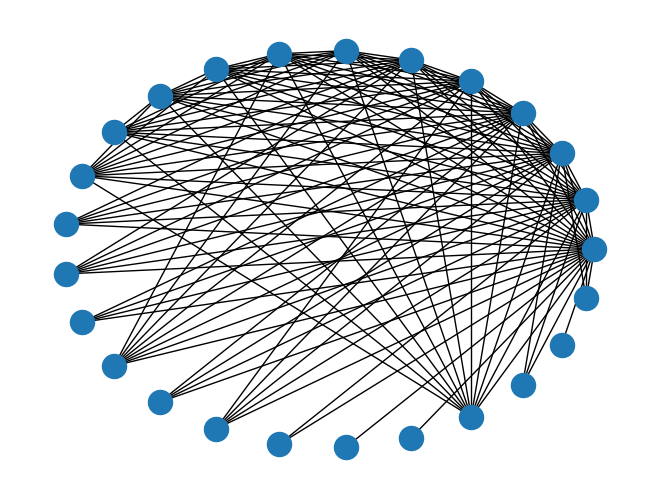

Probailities: [0.9217407339310254, 0.8111318458593023, 0.7742622165020613, 0.7005229577875792, 0.6267836990730973, 0.5899140697158562, 0.5161748110013742, 0.5161748110013742, 0.44243555228689213, 0.4793051816441332, 0.40556592292965116, 0.44243555228689213, 0.2580874055006871, 0.2580874055006871, 0.18434814678620506, 0.33182666421516915, 0.18434814678620506, 0.22121777614344607, 0.11060888807172303, 0.07373925871448203, 0.07373925871448203, 0.4793051816441332, 0.14747851742896406, 0.07373925871448203, 0.14747851742896406]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), 

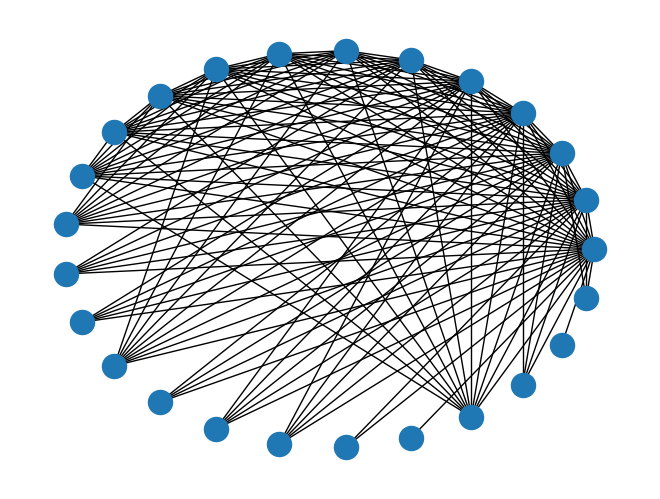

Probailities: [0.9180136496979798, 0.8445725577221415, 0.8078520117342222, 0.771131465746303, 0.6976903737704646, 0.5875287358067071, 0.5508081898187879, 0.5508081898187879, 0.5508081898187879, 0.5140876438308687, 0.4773670978429495, 0.4773670978429495, 0.4039260058671111, 0.25704382191543435, 0.22032327592751516, 0.36720545987919195, 0.18360272993959598, 0.22032327592751516, 0.22032327592751516, 0.11016163796375758, 0.07344109197583838, 0.4773670978429495, 0.18360272993959598, 0.07344109197583838, 0.14688218395167676]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11

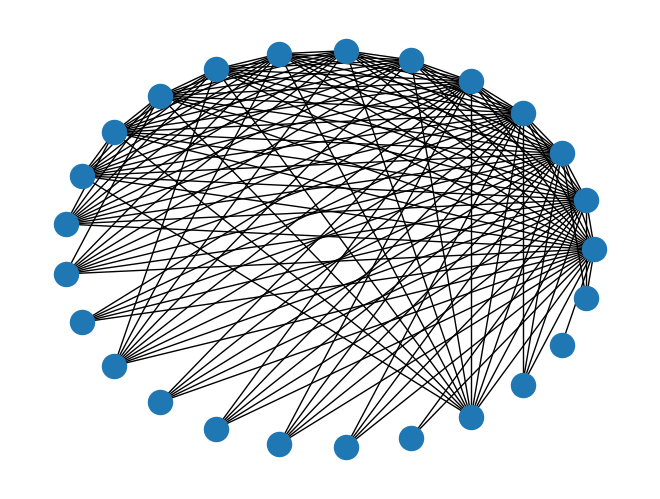

Probailities: [0.9556712949751227, 0.9174444431761178, 0.8792175913771128, 0.8409907395781079, 0.7645370359800981, 0.6116296287840784, 0.6116296287840784, 0.6116296287840784, 0.5734027769850736, 0.5734027769850736, 0.5351759251860686, 0.4969490733870638, 0.4587222215880589, 0.3822685179900491, 0.22936111079402946, 0.3822685179900491, 0.22936111079402946, 0.22936111079402946, 0.22936111079402946, 0.19113425899502454, 0.11468055539701473, 0.4969490733870638, 0.19113425899502454, 0.0764537035980098, 0.1529074071960196]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5

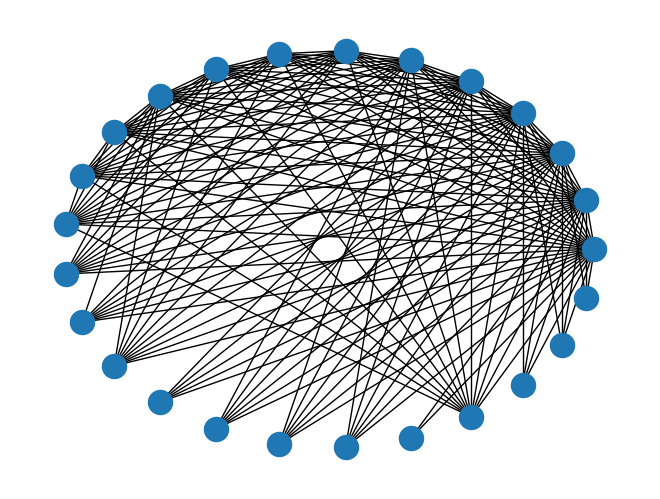

Probailities: [0.9595534362686552, 0.9595534362686552, 0.921171298817909, 0.8827891613671627, 0.8060248864656704, 0.767642749014924, 0.6524963366626855, 0.6141141992119393, 0.6141141992119393, 0.6524963366626855, 0.5373499243104469, 0.5373499243104469, 0.5373499243104469, 0.42220351195820827, 0.3454392370567158, 0.42220351195820827, 0.23029282470447726, 0.26867496215522346, 0.26867496215522346, 0.26867496215522346, 0.11514641235223863, 0.5373499243104469, 0.191910687253731, 0.191910687253731, 0.15352854980298483]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5), 

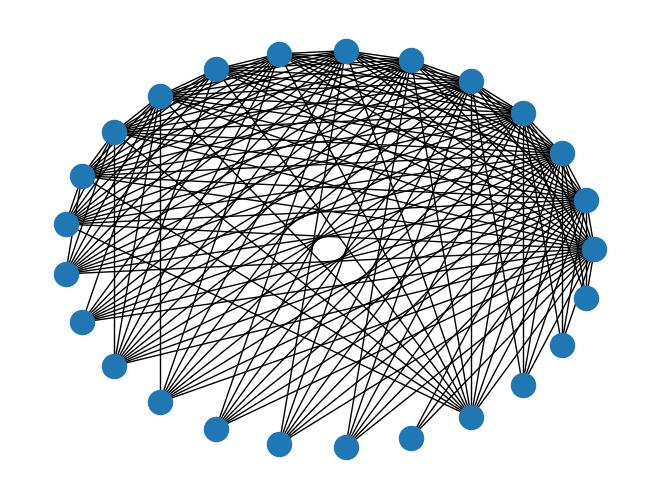

Probailities: [0.9770892388266313, 0.9770892388266313, 0.9770892388266313, 0.9380056692735662, 0.8598385301674357, 0.8207549606143704, 0.7816713910613051, 0.7035042519551746, 0.6253371128490441, 0.7035042519551746, 0.6253371128490441, 0.5862535432959789, 0.5471699737429135, 0.5080864041898483, 0.39083569553065256, 0.4690028346367831, 0.39083569553065256, 0.31266855642452207, 0.31266855642452207, 0.27358498687145677, 0.15633427821226104, 0.5471699737429135, 0.23450141731839155, 0.19541784776532628, 0.19541784776532628]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11,

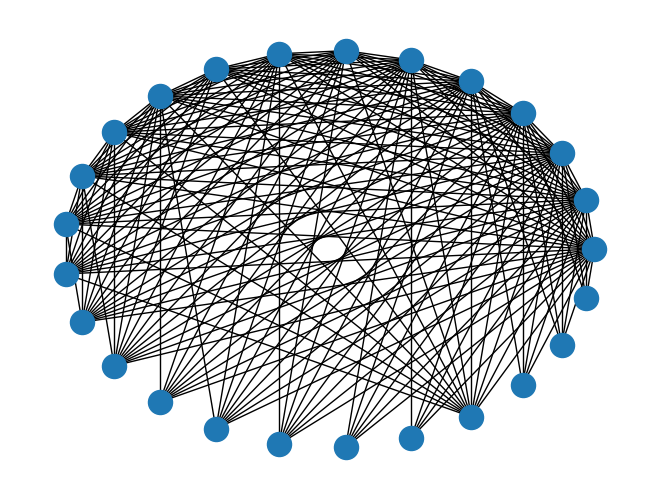

Probailities: [1.0009032122660122, 1.0009032122660122, 1.0009032122660122, 1.0009032122660122, 0.9208309552847312, 0.8807948267940907, 0.8007225698128098, 0.8007225698128098, 0.6806141843408883, 0.7606864413221692, 0.6806141843408883, 0.6806141843408883, 0.6405780558502479, 0.6005419273596073, 0.5605057988689668, 0.5204696703783264, 0.4003612849064049, 0.4003612849064049, 0.3603251564157644, 0.2802528994344834, 0.24021677094384292, 0.6005419273596073, 0.24021677094384292, 0.24021677094384292, 0.20018064245320244]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5), 

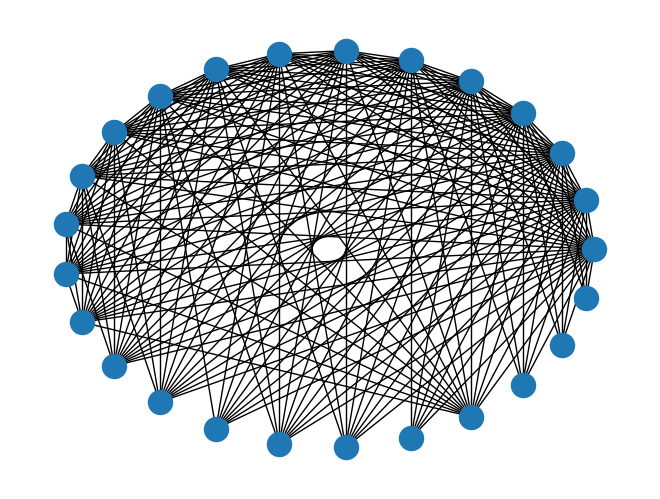

Probailities: [1.030584683696989, 1.030584683696989, 1.030584683696989, 1.030584683696989, 0.9893612963491094, 0.94813790900123, 0.8656911343054707, 0.8656911343054707, 0.8244677469575913, 0.8244677469575913, 0.7420209722618321, 0.7420209722618321, 0.7007975849139526, 0.6595741975660729, 0.6595741975660729, 0.5771274228703139, 0.5359040355224343, 0.41223387347879564, 0.45345726082667515, 0.41223387347879564, 0.28856371143515697, 0.6595741975660729, 0.28856371143515697, 0.24734032408727735, 0.20611693673939782]
Edges: [(0, 17), (0, 24), (5, 0), (6, 0), (11, 0), (15, 0), (7, 0), (15, 1), (21, 0), (5, 1), (21, 1), (0, 1), (7, 1), (2, 0), (5, 2), (11, 1), (5, 3), (5, 4), (1, 2), (7, 2), (0, 3), (21, 2), (1, 3), (11, 2), (21, 3), (21, 4), (2, 3), (9, 0), (1, 4), (7, 3), (22, 0), (1, 6), (4, 0), (17, 1), (0, 8), (1, 8), (3, 4), (5, 6), (7, 4), (24, 1), (0, 10), (4, 2), (5, 7), (15, 2), (21, 5), (22, 1), (5, 8), (7, 6), (11, 3), (0, 12), (9, 1), (11, 4), (15, 3), (0, 13), (5, 9), (11, 5), (17

ValueError: probabilities are not non-negative

In [43]:
# behaviour over a month of the network
for t in range(100):
    synth.change_with_respect_to_time(t)

    # [] detected problem -> from a certain point of the graph probability is too big and the graph looses the property of 
    # a free scale graph
    synth.draw_graph()
    print(f"Probailities: {synth.P}")
    print(f"Edges: {synth.E}")

## Ideas 
---

[-] for the probability of adding edges we compute the probability based on the 
[-] select per time only one edge from the available edges of each Node

In [49]:
# for t in range(15):
#     prob = synth.calc_differential_probability(t)
#     print(prob)

len(synth.available_E)
print(synth.degrees[5])

22


In [ ]:
"""2025: 5.24 billion active users (+4.1%)
        2024: 5.04 billion active users (+5.8%)
        2023: 4.76 billion active users (+3%)
        2022: 4.62 billion active users (+10%)
        2021: 4.20 billion active users (+13%)
        2020: 3.71 billion active users (+7.2%)
        2019: 3.46 billion active users (+8.3%)
        2018: 3.20 billion active users (+15%)
        2017: 2.79 billion active users (+21%)
        2016: 2.31 billion active users (+11%)
        2015: 2.08 billion active users 
        
"""
s = SynthNetwork(None)


None
None
[(0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (0, 18), (0, 19), (0, 20), (0, 21), (0, 22), (0, 23), (0, 24), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (2, 0), (2, 1), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17), (2, 18), (2, 19), (2, 20), (2, 21), (2, 22), (2, 23), (2, 24), (3, 0), (3, 1), (3, 2), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (3, 10), (3, 11), (3, 12), (3, 13), (3, 14), (3, 15), (3, 16), (3, 17), (3, 18), (3, 19), (3, 20), (3, 21), (3, 22), (3, 23), (3, 24), (4, 0), (4, 1), (4, 2), (4, 3), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (4, 10), (4, 11), (4, 12), (4, 13), (4, 14), (4, 15), (4, 16), (4, 17), (4, 18), (4, 19), (4, 20), (4, 21